# Staffing compare DRG B

## Notes 
### Codes For Cost Bases
"Pupil Basis: 1 = Enrollment plus outplaced pupils, 2 = Enrollment in district schools, 4 = Outplaced pupils"
"Pupil Basis: 1 = Enrollment plus outplaced pupils, 2 = Enrollment in district schools, 3 = Total pupils transported"

See SES at 
https://ctdatahaven.org/data-dashboard/connecticut-town-data-viewer/


SocioEconomic Data from National Center for Education Statistics https://nces.ed.gov/programs/edge/Home

In [1]:
import os
from os import path, mkdir
import glob
import re
import warnings
from datetime import datetime
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.decomposition import PCA

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
def split_function(x):
    return x.replace(" - ", ":\n").title()

In [3]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"
    
def dollar_k1(x, pos):
    return f"${int(x/1000):,.1f}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_k1_formatter = ticker.FuncFormatter(dollar_k1)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [4]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Title': "Peer Educational Comparisons",
'Author': 'Joel Danke',
'Description': "Comparing Granby school performance to other schools with selected benchmarking groups",
'Creation Time': rundate,
'Software': software}

## Read data

In [5]:
# all have the "grouping" vars JSG, % w/Bachelors, etc.
totalstaff = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/totalstaff.parquet')
function_exp = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/expenditures.parquet')
accountability = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/accountability.parquet')

# just district & year, also Category is used to split
school_accountability = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/accountability_schools.parquet')

In [6]:
# income data
income_vars =  ['District', 'Fiscal Year End', 'Size of adjusted gross income', 'Income Per Taxpayer', 'Equalized Net Grand List Per Taxpayer',
                'Real Income Per Taxpayer', 'Real Disposable Income Per Taxpayer', 'Real Equalized Net Grand List Per Taxpayer',
                'Debt Service Share Of Budget', 'Education Share Of Budget', 'Education Share Of Eq Grand List', 'Education Share Of Income', 'Taxpayers']

district_total_income = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_incomes.parquet')[income_vars]
district_total_income = district_total_income[district_total_income['Size of adjusted gross income'] == 'Total'].copy()

# re-use 2022 as 2023
district_total_2023 = district_total_income[district_total_income['Fiscal Year End'] == 2023].copy()
district_total_2023['Fiscal Year End'] = district_total_2023['Fiscal Year End'] + 1
district_total_income = pd.concat([district_total_income, district_total_2023], ignore_index=True)

# make school year as the one that starts the next fiscal year
district_total_income['School Year'] = (district_total_income['Fiscal Year End'] + 1).astype('str')

In [7]:
# population (has extra year from municipal grand list
popdf_districts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/population_district.parquet')
# as string to join
popdf_districts['School Year'] = popdf_districts['Year'].astype('str')
popdf_districts.drop(columns=['Year'], inplace=True)

## Filter data to "Peer Group"
Dropping Southington - it is just too large!

In [49]:
# peer selection
PEERVAR = "finprojB"
peer_condition = f"{PEERVAR} > 0"

PEERTEXT = "DRG B"

#make directory if needed
try:
    mkdir(f"./charts/peer_districts/{PEERVAR}")
except FileExistsError:
    pass
#make directory if needed
try:
    mkdir(f"./charts/staffing/{PEERVAR}")
except FileExistsError:
    pass
    
try:
    mkdir(f"./charts/accountability/{PEERVAR}")
except FileExistsError:
    pass
try:
    mkdir(f"./charts/expenditures/{PEERVAR}")
except FileExistsError:
    pass

### Staffing
This includes regional schools that are 7-12 or 9-12 only. It might be "more fair" to include only K-12 institutions.

In [9]:
# ignore elementary districts
totalstaff['SpecialEd Share Of Ed'] = (totalstaff['SpecialEd'] / (totalstaff['Educational'] + totalstaff['SpecialEd']))
peerstaff = totalstaff[(totalstaff['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                       (totalstaff['High Grade'] == 12) & (totalstaff['Year'] > '2009')]\
            .query(peer_condition).copy()

peerstaff = peerstaff[~peerstaff['District'].str.startswith('Southington')]
peerstaff.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)

### Expenditures

#### Object Expenditures
Used as an estimate of overhead costs. Salaries are not subdivided by instructional, admin, custodial.

**Purchased Services** – Services rendered by organizations or
personnel not on the payroll of the school district. Although
a product may or may not result from the transaction, the
primary reason for the purchase is the service provided.  
**Supplies** – Items that are consumed, are worn out, or have
deteriorated through use or items that lose their identity
through fabrication or incorporation into different or more
complex units or substances. Includes, for example, 
instructional supplies such as textbooks, office supplies,
electricity, and fuel.  
**Property** – Purchases of equipment, furniture, equipment,
and for minor school construction projects such as for roof
replacement, energy conservation, or updates to comply
with building codes.  
**Other** – Expenditures not included in the other objects.  
**Tuition** – Line shown if greater than 5 applicable pupils.
Reimbursements to other educational entities for
instructional services to students residing within the legal
boundaries of the paying school district.


**Budget Book**  
**Largest Benefit Increase + \$346K**: Board's contribution to the Granby Health Benefit Fund for employee medical/dental insurance. The budget includes a slight premium increase, as well as census changes. Additionally, **commencing in FY27,** additional OPEB contributions are being paid by the Board of Education to meet the Actuarily Determined Contribution (ADC).  

**Purchased Services**:  
**Educational Services \$595K**: Includes funds for services including copiers, substitutes, curriculum development activities, **school resource officer benefits**, purchased instructional services for virtual classes, etc.   
**Support Services \$540K**: Includes funds for health service and physician fee contracted services. Contracted nursing services will increase 5% in FY27.  
**Support Services \$262K**: Includes funds for special education support services for evaluation services required by law. This budget also supports the Alternative Learning Center at the middle school/high school and training for teachers to deliver specialized reading instruction. The increase reflects **higher School Resource Officer benefits**, increased subsitute service rates, and hazardous waste disposal costs for science laboratories.  
**P/L Insurance \$120K**: Includes funds for property, auto, legal liability and cyber insurance.  
**Legal Fees \$69K**: Includes funds for legal fees associated with legal compliance, employee relations and grievances, internal investigations, risk management and defense, complex matters surrounding education, as well as collective bargaining, complex special education matters and due process hearings.

#### Functional Expenditures

**Instruction**  
Activities dealing directly with the interaction between teachers and students. Teaching may be provided for students in a school classroom or in another location.  

**Support services – students**  
Activities providing student support services designed to assess and improve the well-being of students and to supplement the teaching process. This includes guidance, social, and health services.  

**Support Services – instruction**  
Activities assisting the instructional staff with the content and process of providing learning experiences for students not reported as Improving Instruction or Library and media service.  

**Support Services – general administration**  
Activities of the board of education and the superintendent's office.  

**Support Services – school-based administration**  
Activities concerned with the administrative responsibility of directing and managing the operation of a school, such as the principal's office.  

**Central and other support services**  
Activities that support other administrative and instructional functions, including fiscal services, human resources, planning, and administrative information technology, and other support services not included elsewhere.  

**Operation and maintenance of plant**  
Activities concerned with keeping the physical plant open, comfortable and safe for use and with keeping the grounds, buildings, and equipment in effective working condition and state of repair.  

**Student transportation services**
Activities providing transportation to and from home, for field trips, and for athletic activities.  

**Food services**  
Activities concerned with providing food to students and staff in a school or school district. This report includes only expenditures from local funds used to cover an operating deficit in the food service program, where revenue from child nutrition grants, fees, and other sources is insufficient to cover all expenses.

**Enterprise operations**  
Activities for enterprise operations, i.e. activities that are financed and operated in a manner similar to private business enterprises, for example a school bookstore. Also includes athletics, bands, dramatics, and any school activity paid by local appropriations. Does not include any student activity funds.

**Minor school construction**  
Activities concerned with minor school construction projects, such as for roof replacement, energy conservation, or updates to comply with building codes. (Applies to years earlier than 2019-20 only.)  

In [10]:
# filter to remove non-essential schools, functions
peer_expenditures = function_exp[(function_exp['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                (~function_exp['Function'].isin(['Minor school construction', 'Enterprise operations', 'Food services'])) &
                                (function_exp['High Grade'] == 12)]\
                    .query(peer_condition).copy()

# not sure this is used
peer_ave = peer_expenditures.groupby(['Function', 'Year'])['PPE Growth'].median().reset_index().rename(columns={'PPE Growth': 'Median PPE Growth'})
peer_expenditures = peer_expenditures.merge(peer_ave, how='left', on=['Function', 'Year'])

peer_expenditures = peer_expenditures[~peer_expenditures['District'].str.startswith('Southington')]
peer_expenditures['School Year'] = peer_expenditures['Year'].str.slice(0,4)
peer_expenditures.sort_values(by=['School Year', 'Function', 'District'], inplace=True)

In [11]:
peer_expenditures.groupby('Function').agg({'District': 'nunique', 'Year': 'nunique'})

,District,Year
Function,,
Administration and Support Services,18,5
Central and other support services,18,8
Employee Benefits,18,8
Instruction,18,13
Operation and maintenance of plant,18,13
Salaries,18,8
Services And Supplies,18,8
Student transportation services,18,13
Support services - general administration,18,13


In [12]:
peer_expenditures.groupby('Function').agg({'Year': 'max'})

,Year
Function,
Administration and Support Services,2016-17
Central and other support services,2024-25
Employee Benefits,2024-25
Instruction,2024-25
Operation and maintenance of plant,2024-25
Salaries,2024-25
Services And Supplies,2024-25
Student transportation services,2024-25
Support services - general administration,2024-25


### Accountability

**NO Southington**  
**No Covid Years**  

Connecticut's Next Generation Accountability reports for 2017-18 didn't show science scores because the state administered a field test (Smarter Science Field Test) instead of the regular CMT/CAPT science tests. 

In 2017-18, Connecticut's Next Generation Accountability system integrated Smarter Balanced tests (ELA/Math) with the new Next Generation Science Standards (NGSS) assessment, a field test/pilot for Grades 5, 8, and 11, aligning science with modern standards and transitioning from older science measures to a more comprehensive, standards-based approach for college/career readiness. Schools used multiple indicators, including these assessments, to show progress. 

In [13]:
# remove nonessential schools
peer_accountability = accountability[(accountability['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                     (accountability['High Grade'] == 12)]\
                     .query(peer_condition).copy()

peer_accountability = peer_accountability[~peer_accountability['District'].str.startswith('Southington')]

peer_accountability.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)
peer_accountability['School Year'] = peer_accountability['Year'].str.slice(0,4).astype('int')

## Combine accountability, expenditures, staffing

Select columns to avoid duplicates.

In [14]:
# Avoid duplicating clustering variables when getting staff data
peerdrop = [x for x in peerstaff.columns if ((x in peer_expenditures.columns) & (x not in ['Year', 'District']))]

# For accountability index select only necessary variables
values = ['Math PI', 'Math Growth', 'ELA PI', 'ELA Growth', 'Science PI',
          'CCR - Taking Courses', 'CCR - Passing Exams', 'Postsecondary Entrance', 
          'On-track to HS Graduation', '4-yr Graduation', 'Chronic Absenteeism',
          'Physical Fitness', 'Arts Access', 'Accountability Index']

high_need = ['ELA PI - High Needs',  'ELA Growth - High Needs', 
             'Math PI - High Needs', 'Math Growth - High Needs',
             'Science PI - High Needs', 'Chronic Absenteeism - High Needs', '6-yr Graduation - High Needs']

### Total Expenditures

In [15]:
# filter to only one Function per district per year
# get other type of expenditures for reporting only

_benefits = peer_expenditures[peer_expenditures['Function'] == 'Employee Benefits'][['Year', 'District', 'PPE', 'Expenditures', 'Real Expenditures']]\
                             .rename(columns={'PPE': 'Benefits Per Student', 'Expenditures': 'Benefits', 'Real Expenditures': 'Real Benefits'}).copy()

_services = peer_expenditures[peer_expenditures['Function'] == 'Services And Supplies'][['Year', 'District', 'PPE', 'Real PPE']]\
                             .rename(columns={'PPE': 'Purchased Services Per Student', 'Real PPE': 'Real Purchased Services Per Student'}).copy()

# ONLY "total" expenditures, accountability index
peer_combined = peer_expenditures[peer_expenditures['Function'] == 'Total']\
                .merge(_benefits,  how='left', on=['Year', 'District'])\
                .merge(_services,  how='left', on=['Year', 'District'])\
                .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])\
                .merge(popdf_districts, how='left', on=['School Year', 'District'])\
                .merge(district_total_income, how='left', on=['School Year', 'District'])

peer_combined['% Student'] = peer_combined['Enrollment'] / peer_combined['Population']
peer_combined['Expenditures Per Student'] = peer_combined['Expenditures'] / peer_combined['Enrollment']
peer_combined['Real Expenditures Per Student'] = peer_combined['Real Expenditures'] / peer_combined['Enrollment']

peer_combined['Benefits Per FTE'] = peer_combined['Benefits'] / peer_combined['FTE Count']
peer_combined['Real Benefits Per FTE'] = peer_combined['Real Benefits'] / peer_combined['FTE Count']

peer_combined['Non-Instruction $ Per Student'] = peer_combined['Expenditures Per Student'] - peer_combined['Instruction $ Per Student']
peer_combined['Real Non-Instruction $ Per Student'] = peer_combined['Real Expenditures Per Student'] - peer_combined['Real Instruction $ Per Student']

peer_combined['Payroll Less Instruction Per Student'] = peer_combined['Payroll Per Student'] - peer_combined['Instruction $ Per Student']
peer_combined['Real Payroll Less Instruction Per Student'] = peer_combined['Real Payroll Per Student'] - peer_combined['Real Instruction $ Per Student']

### Instructional Expenditures

In [16]:
# ONLY "instructional" expenditures only
peer_instruction = peer_expenditures[peer_expenditures['Function'] == 'Instruction']\
                   .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                   .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])

peer_instruction.sort_values(by=['District', 'Year'], inplace=True)
peer_instruction.reset_index(inplace=True, drop=True)

### Derivations

In [17]:
# help w/plotting styles
peerstaff[PEERVAR] = peerstaff[PEERVAR].where(~peerstaff['District'].str.startswith('Region'), 3)
peer_expenditures[PEERVAR] = peer_expenditures[PEERVAR].where(~peer_expenditures['District'].str.startswith('Region'), 3)
peer_accountability[PEERVAR] = peer_accountability[PEERVAR].where(~peer_accountability['District'].str.startswith('Region'), 3)
peer_combined[PEERVAR] = peer_combined[PEERVAR].where(~peer_combined['District'].str.startswith('Region'), 3)
peer_instruction[PEERVAR] = peer_instruction[PEERVAR].where(~peer_instruction['District'].str.startswith('Region'), 3)

### Detailed Accountability

In [18]:
distcols = list(peer_accountability.drop(columns=values+high_need).columns)
distcols = [x for x in distcols if ((x.find('Progress') < 0) & (x.find(' Grade') < 0))]

school_accountability = school_accountability.merge(peer_accountability[distcols].drop(columns=['School Year']), how='inner', on=['District', 'Year'])
district_accountability = school_accountability.query('Category == "District"')
school_accountability = school_accountability.query('Category == "School"')

In [19]:
district_accountability.shape, school_accountability.shape

((5994, 46), (45325, 46))

## Peer Overview

In [20]:
idx = pd.IndexSlice
slice_ = idx[idx["Granby School District"], idx[:]]

_d = peer_combined.query('Year == "2024-25"')[['District', 'Equalized Net Grand List Per Taxpayer', 'Income Per Taxpayer',
                                               'Education Share Of Income', 'Expenditures', 'Enrollment', 'Accountability Index',
                                              'High Needs Students Share of Enrollment', 'Students w/ Disabilities Share of Enrollment',
                                               'Expenditures Per Student', 'Instruction $ Per Student', 'Non-Instruction $ Per Student',
                                               'Payroll Less Instruction Per Student', 'Purchased Services Per Student']]\
        .rename(columns = {'High Needs Students Share of Enrollment': 'High Needs %',
                          'Students w/ Disabilities Share of Enrollment': 'w/Disability %',})\
    .sort_values('Instruction $ Per Student').copy()


_d.drop(columns=['Expenditures Per Student'], inplace=True)

_d.set_index('District', inplace=True)
_d.style.format({"Accountability Index": "{:,.1f}"} | { "Expenditures": lambda x: f"${(x/1000000):,.1f}MM"} |
                  { x: "${:,.0f}" for x in ["'Payroll Less Instruction Per Student'", 'Instruction $ Per Student', 'Non-Instruction $ Per Student', 'Payroll Less Instruction Per Student',
                                            'Non-Instruction $ Per Student', 'Purchased Services Per Student', 'Equalized Net Grand List Per Taxpayer', 'Income Per Taxpayer']} |
                  { x: "{:,.1%}" for x in ['Education Share Of Income', 'w/Disability %', 'High Needs %']} |
                  {'Enrollment': "{:,.0f}"} )\
    .set_properties(**{"background-color": "#ffffb3", 'font-weight' : 'bold'}, subset=slice_)\
    .set_caption("2024-2025 School Year Key Stats")\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


,Equalized Net Grand List Per Taxpayer,Income Per Taxpayer,Education Share Of Income,Expenditures,Enrollment,Accountability Index,High Needs %,w/Disability %,Instruction $ Per Student,Non-Instruction $ Per Student,Payroll Less Instruction Per Student,Purchased Services Per Student
District,,,,,,,,,,,,
Trumbull School District,"$279,447","$93,695",5.7%,$141.0MM,"6,943",84.7,33.4%,15.2%,"$10,881","$9,420","$4,898","$3,634"
South Windsor School District,"$281,334","$82,630",5.9%,$99.4MM,"5,125",82.3,33.6%,12.9%,"$11,721","$7,678","$3,984","$3,099"
Farmington School District,"$358,675","$113,281",4.0%,$90.1MM,"4,195",85.3,31.6%,13.4%,"$12,922","$8,556","$3,532","$3,740"
Rocky Hill School District,"$288,771","$74,345",5.3%,$57.2MM,"2,539",82.8,39.3%,15.4%,"$12,928","$9,614","$5,178","$3,867"
Cheshire School District,"$280,166","$102,813",4.4%,$91.8MM,"4,317",85.4,29.8%,14.7%,"$13,277","$7,980","$3,832","$3,622"
Brookfield School District,"$305,868","$88,660",5.0%,$57.5MM,"2,542",81.9,34.1%,14.2%,"$13,303","$9,313","$3,819","$4,096"
Granby School District,"$236,361","$91,622",5.1%,$39.0MM,"1,709",82.8,30.7%,17.5%,"$13,396","$9,444","$3,689","$4,373"
Monroe School District,"$305,784","$87,743",6.0%,$74.0MM,"3,458",79.6,28.1%,17.2%,"$13,456","$7,939","$3,540","$3,323"
Simsbury School District,"$271,677","$113,677",4.4%,$93.7MM,"4,127",81.4,30.7%,17.8%,"$13,526","$9,180","$4,334","$3,732"


In [21]:
# Largest YoY growth
peer_expenditures[peer_expenditures['Function'] == 'Instruction'].groupby('District')['Real PPE Growth'].max().sort_values()

District
Avon School District             1.067988
Cheshire School District         1.070332
Simsbury School District         1.077260
Glastonbury School District      1.083304
Monroe School District           1.110183
Regional School District 15      1.111290
South Windsor School District    1.115859
Rocky Hill School District       1.126521
Brookfield School District       1.129702
Trumbull School District         1.136743
Fairfield School District        1.144760
Granby School District           1.147319
Guilford School District         1.148258
Farmington School District       1.167976
Oxford School District           1.169817
West Hartford School District    1.171693
Canton School District           1.243347
Greenwich School District        1.671958
Name: Real PPE Growth, dtype: float64

### Year vs 2ago changes
Attempt to comparing instructional and accountability growth. No COVID years is problematic

In [22]:
# calculate % change from prior year
changecols = ['Pupils', 'PPE', 'Instruction $', 'Instruction $ Per Student',
              'Real Instruction $', 'Real PPE', 'Real Instruction $ Per Student',
              'Teachers', 'Educational', 'Student: Teachers Ratio', 'Accountability Index']

# % change vs two years ago
changes = peer_instruction.groupby('District')[changecols].diff(2)/peer_instruction.groupby('District')[changecols].shift(2)

changes = changes.join(peer_instruction[['District', 'Year', 'Town', 'Type', 'Granby']].rename(columns={'Pupils': 'Students'}), how='inner')

changes.head(10).tail(5)

,Pupils,PPE,Instruction $,Instruction $ Per Student,Real Instruction $,Real PPE,Real Instruction $ Per Student,Teachers,Educational,Student: Teachers Ratio,Accountability Index,District,Year,Town,Type,Granby
5,0.021713,0.071772,0.095086,0.071772,0.058537,0.036001,0.036001,-0.029801,-0.025383,0.010636,0.019653,Avon School District,2017-18,Avon,Town,Other
6,-0.005294,0.105747,0.099861,0.105747,0.060986,0.066663,0.066663,-0.068455,-0.082490,0.029084,0.043825,Avon School District,2018-19,Avon,Town,Other
7,-0.022448,0.069055,0.045014,0.069055,0.010089,0.033326,0.033326,0.008289,-0.039272,-0.019305,NaN,Avon School District,2019-20,Avon,Town,Other
8,-0.015352,0.056988,0.040820,0.056988,0.011299,0.027009,0.027009,0.037239,-0.009754,-0.043243,NaN,Avon School District,2020-21,Avon,Town,Other
9,-0.017146,0.099447,0.080572,0.099447,0.004637,0.022186,0.022186,0.008221,0.035284,-0.026215,NaN,Avon School District,2021-22,Avon,Town,Other


## Color Scheme

In [23]:
# color scheme
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in peer_combined['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .4),
             2: 'black',
             1: (0.529, 0.808, 0.922, .4)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}

## Special Education Staffing

In [24]:
# Cell used to create legend
_ave = pd.DataFrame(peerstaff.groupby('Year')['High Needs Students Share of Enrollment'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

ax = sns.lineplot(data=tmpdf[(tmpdf['District'] == 'Average') | (tmpdf['Town'] == 'Granby') | (tmpdf['Town'] == 'Somers')],
                y='High Needs Students Share of Enrollment', x='Year', hue='District',
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

# Custom legend format
h, lab = ax.get_legend_handles_labels()
h[2].set_dashes((5, 1.2))
lab[1] = 'Peer District'
lab[2] = 'Granby'
lab[3] = 'Peer Average'

indices = [2, 3, 1]
_handles = [h[i] for i in indices]
_labels = [lab[i] for i in indices]

# how to use it
ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)


plt.close()

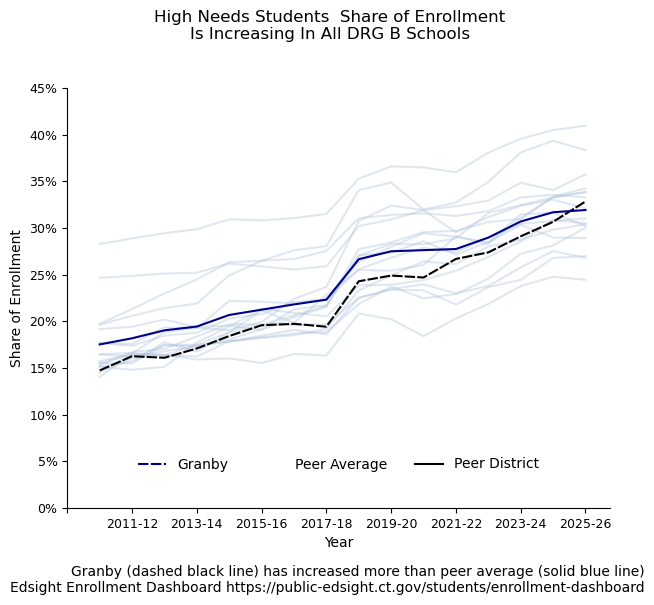

In [25]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['High Needs Students Share of Enrollment'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle(f"High Needs Students  Share of Enrollment\nIs Increasing In All {PEERTEXT} Schools")

ax = sns.lineplot(data=tmpdf,
                y='High Needs Students Share of Enrollment', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
ax.tick_params(axis='both', labelsize=9)
labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Share of Enrollment')
ax.set_ylim(0, .45)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Granby (dashed black line) has increased more than peer average (solid blue line)\n"
line2 = "Edsight Enrollment Dashboard https://public-edsight.ct.gov/students/enrollment-dashboard"
fig.text(.95, .01, line1 + line2 , fontsize=10, ha='right')

plt.show()

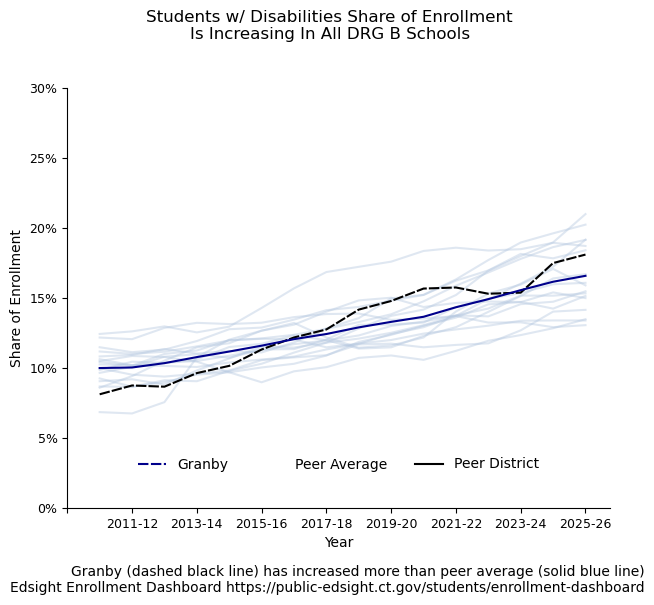

In [26]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['Students w/ Disabilities Share of Enrollment'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle(f"Students w/ Disabilities Share of Enrollment\nIs Increasing In All {PEERTEXT} Schools")

ax = sns.lineplot(data=tmpdf,
                y='Students w/ Disabilities Share of Enrollment', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
ax.tick_params(axis='both', labelsize=9)

ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Share of Enrollment')
ax.set_ylim(0, .3)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Granby (dashed black line) has increased more than peer average (solid blue line)\n"
line2 = "Edsight Enrollment Dashboard https://public-edsight.ct.gov/students/enrollment-dashboard"
fig.text(.95, .01, line1 + line2 , fontsize=10, ha='right')

plt.savefig(f"./charts/staffing/{PEERVAR}/special_ed_enrollment.png", dpi=200, metadata=png_metadata)

plt.show()

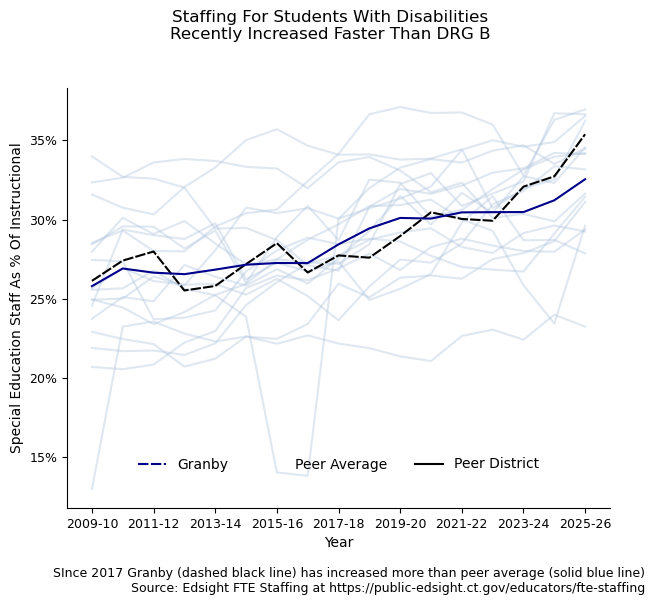

In [27]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['Special Ed Share of Instructional'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle(f"Staffing For Students With Disabilities\nRecently Increased Faster Than {PEERTEXT}")

ax = sns.lineplot(data=tmpdf,
                y='Special Ed Share of Instructional', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
ax.tick_params(axis='both', labelsize=9)

labels = ax.xaxis.get_ticklabels()
#labels[0].set_visible(False)
ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Special Education Staff As % Of Instructional')
#ax.set_ylim(0, .3)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "SInce 2017 Granby (dashed black line) has increased more than peer average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=9, ha='right')

plt.show()

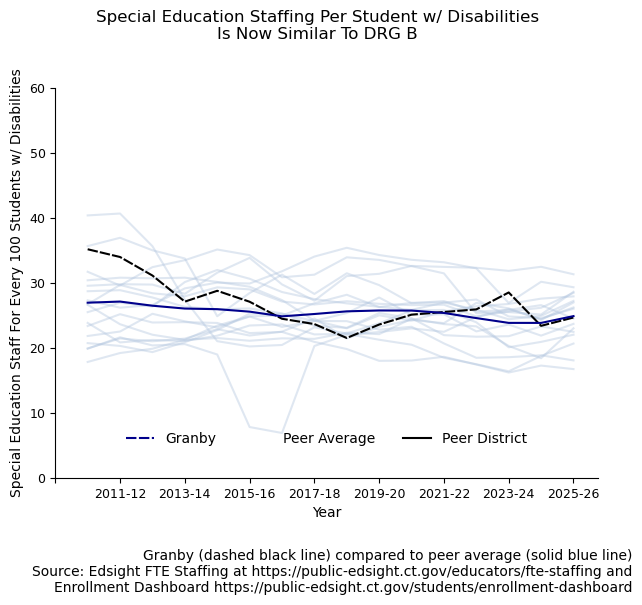

In [28]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['SpecialEd Per 100 Student w/ Disabilities'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle(f"Special Education Staffing Per Student w/ Disabilities\nIs Now Similar To {PEERTEXT}")

ax = sns.lineplot(data=tmpdf,
                y='SpecialEd Per 100 Student w/ Disabilities', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
ax.tick_params(axis='both', labelsize=9)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
#ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Special Education Staff For Every 100 Students w/ Disabilities')
ax.set_ylim(0, 60)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.2)

line1 = "Granby (dashed black line) compared to peer average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing and\n"
line3 = "Enrollment Dashboard https://public-edsight.ct.gov/students/enrollment-dashboard"
fig.text(.95, .01, line1 + line2 + line3 , fontsize=10, ha='right')

plt.show()

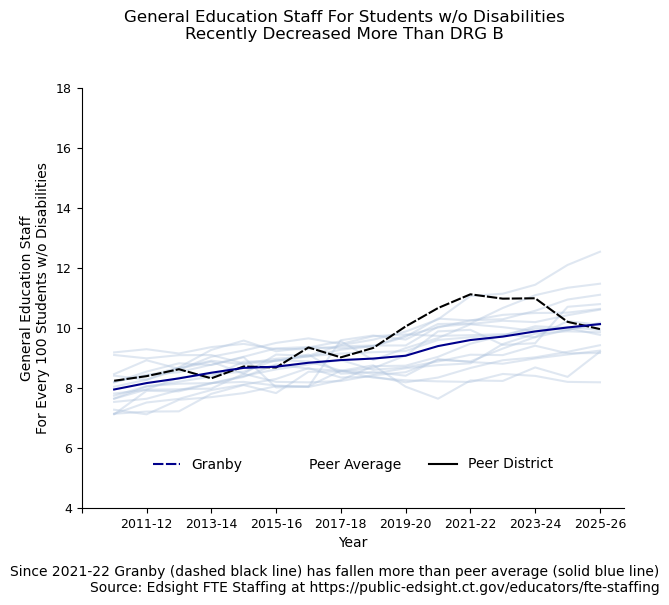

In [29]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['Educational Per 100 Student w/o Disabilities'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}



fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle(f"General Education Staff For Students w/o Disabilities\nRecently Decreased More Than {PEERTEXT}")

ax = sns.lineplot(data=tmpdf,
                y='Educational Per 100 Student w/o Disabilities', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
ax.tick_params(axis='both', labelsize=9)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
#ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('General Education Staff\nFor Every 100 Students w/o Disabilities')
ax.set_ylim(4, 18)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Since 2021-22 Granby (dashed black line) has fallen more than peer average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=10, ha='right')

plt.show()

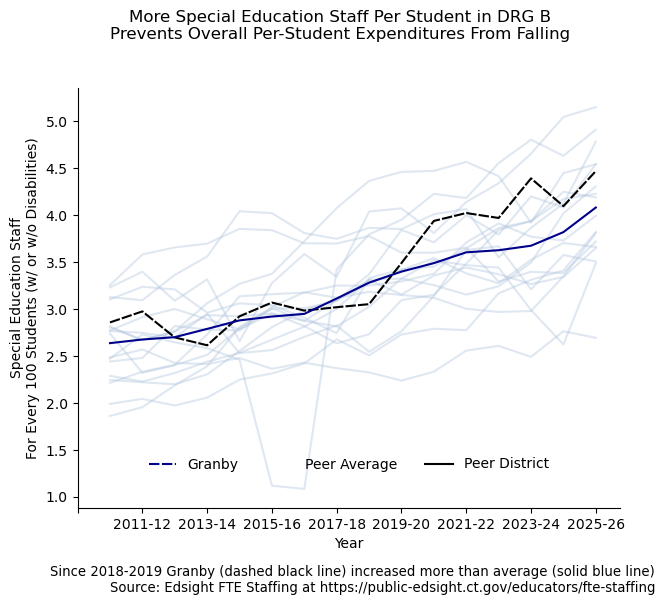

In [30]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['SpecialEd Per 100 Student'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle(f"More Special Education Staff Per Student in {PEERTEXT}\nPrevents Overall Per-Student Expenditures From Falling")

ax = sns.lineplot(data=tmpdf,
                y='SpecialEd Per 100 Student', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
#ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('Special Education Staff\nFor Every 100 Students (w/ or w/o Disabilities)')
#ax.set_ylim(0, 60)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Since 2018-2019 Granby (dashed black line) increased more than average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=9.5, ha='right')

plt.show()

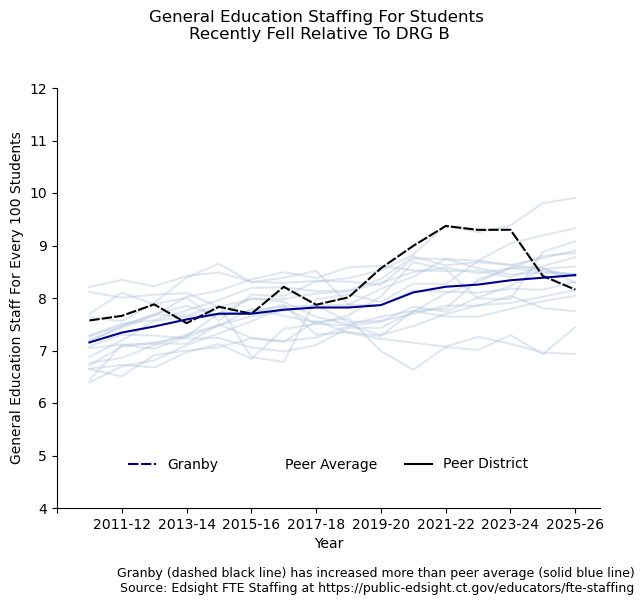

In [31]:
_ave = pd.DataFrame(peerstaff.groupby('Year')['Educational Per 100 Student'].mean()).reset_index(drop=False)
_ave['District'] = 'Average'
_ave['Granby'] = 'Other'
tmpdf = pd.concat([peerstaff, _ave], axis=0, ignore_index=True)

# colors - move this if needed
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in tmpdf['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}



fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle(f"General Education Staffing For Students \nRecently Fell Relative To {PEERTEXT}")

ax = sns.lineplot(data=tmpdf,
                y='Educational Per 100 Student', x='Year', hue='District', legend=None,
                style='Granby', sizes=[9, 27], dashes=[(None, None), (5, 1)], palette=school_cols, ax=ax)

current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)

labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)
#ax.yaxis.set_major_formatter(perci_formatter)
ax.set_ylabel('General Education Staff For Every 100 Students')
ax.set_ylim(4, 12)

ax.legend(_handles, _labels)
sns.move_legend(ax, loc="upper center", bbox_to_anchor=(0.5, 0.15), ncols=3, frameon=False)

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Granby (dashed black line) has increased more than peer average (solid blue line)\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=9, ha='right')

plt.show()

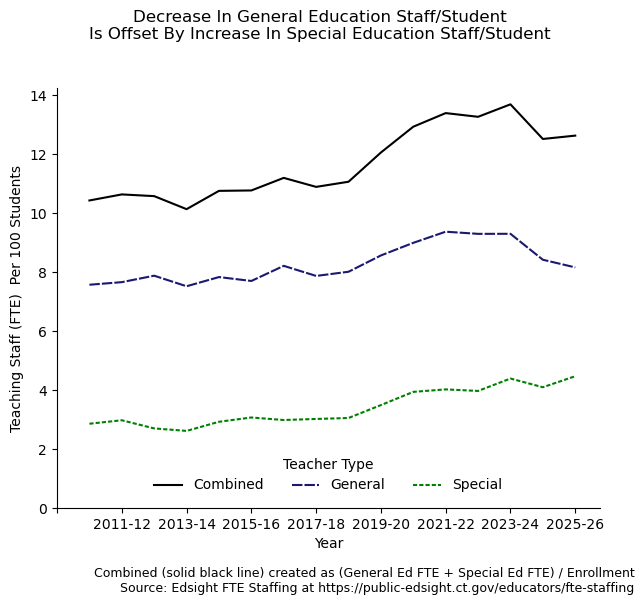

In [32]:
tmpdf = peerstaff.query('Town == "Granby"')

tmpdf = pd.melt(tmpdf, id_vars=['Year'], value_vars=['Instructional Per 100 Student', 'Educational Per 100 Student','SpecialEd Per 100 Student'],
        var_name='type', value_name='value', ignore_index=True)

tmpdf['Teacher Type'] = tmpdf['type'].where(tmpdf['type'].str.startswith('Instructional'), 'General')
tmpdf['Teacher Type'] = tmpdf['Teacher Type'].where(~tmpdf['type'].str.startswith('Special'), 'Special')
tmpdf['Teacher Type'] = tmpdf['Teacher Type'].where(~tmpdf['Teacher Type'].str.startswith('Instructional'), 'Combined')


fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('Decrease In General Education Staff/Student\nIs Offset By Increase In Special Education Staff/Student')

ax = sns.lineplot(data=tmpdf, x='Year', y='value',
                  hue='Teacher Type', palette=['black', 'midnightblue', 'green'],
                  style='Teacher Type', dashes=[(None, None), (5, 1), (2, 1)],
                  ax=ax)

# every other year
current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
labels = ax.xaxis.get_ticklabels()
labels[0].set_visible(False)

ax.set_ylim(bottom=0)
ax.set_ylabel("Teaching Staff (FTE)  Per 100 Students")

sns.move_legend(ax, loc="upper center",
                bbox_to_anchor=(0.5, 0.15), ncols=3,
                frameon=False, )

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.15)

line1 = "Combined (solid black line) created as (General Ed FTE + Special Ed FTE) / Enrollment\n"
line2 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 , fontsize=9, ha='right')

plt.savefig(f"./charts/staffing/{PEERVAR}/special_ed_share_of_staff_granby.png", dpi=200, metadata=png_metadata)

plt.show()

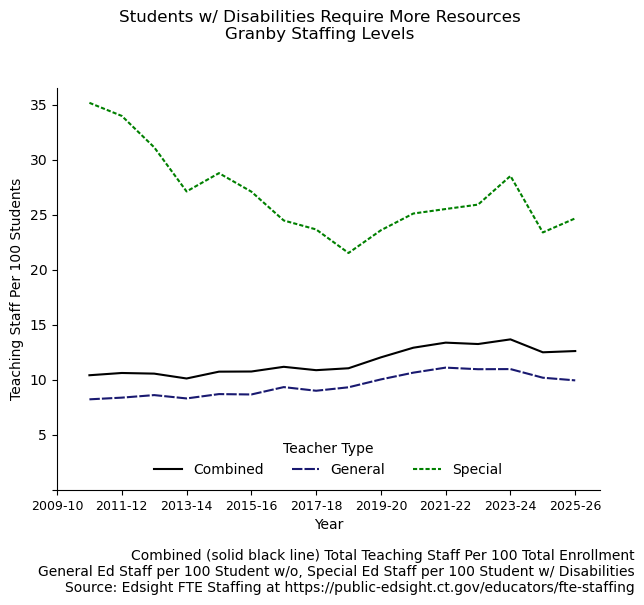

In [33]:
tmpdf = peerstaff.query('Town == "Granby"')
tmpdf = pd.melt(tmpdf, id_vars=['Year'], value_vars=['Instructional Per 100 Student',
                                                     'Educational Per 100 Student w/o Disabilities',
                                                     'SpecialEd Per 100 Student w/ Disabilities'],
        var_name='type', value_name='value', ignore_index=True)

tmpdf['Teacher Type'] = tmpdf['type'].where(tmpdf['type'].str.startswith('Instructional'), 'General')
tmpdf['Teacher Type'] = tmpdf['Teacher Type'].where(~tmpdf['type'].str.startswith('Special'), 'Special')
tmpdf['Teacher Type'] = tmpdf['Teacher Type'].where(~tmpdf['Teacher Type'].str.startswith('Instructional'), 'Combined')


fig, ax = plt.subplots(1, 1, figsize=(7,6))

fig.suptitle('Students w/ Disabilities Require More Resources\nGranby Staffing Levels')

ax = sns.lineplot(data=tmpdf, x='Year', y='value',
                  hue='Teacher Type', palette=['black', 'midnightblue', 'green'],
                  style='Teacher Type', dashes=[(None, None), (5, 1), (2, 1)],
                  ax=ax)

# every other year
current_ticks = ax.get_xticks()
new_ticks = current_ticks[::2]
ax.set_xticks(new_ticks)
labels = ax.yaxis.get_ticklabels()
labels[0].set_visible(False)
plt.xticks(fontsize=9)

ax.set_ylim(bottom=0)
ax.set_ylabel("Teaching Staff Per 100 Students")

sns.move_legend(ax, loc="upper center",
                bbox_to_anchor=(0.5, 0.15), ncols=3,
                frameon=False, )

sns.despine()
plt.subplots_adjust(top=.85, bottom=0.18)

line1 = "Combined (solid black line) Total Teaching Staff Per 100 Total Enrollment\n"
line2 = "General Ed Staff per 100 Student w/o, Special Ed Staff per 100 Student w/ Disabilities\n"
line3 = "Source: Edsight FTE Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
fig.text(.95, .01, line1 + line2 + line3 , fontsize=10, ha='right')

plt.savefig(f"./charts/staffing/{PEERVAR}/teaching_staff_per100_granby.png", dpi=200, metadata=png_metadata)

plt.show()

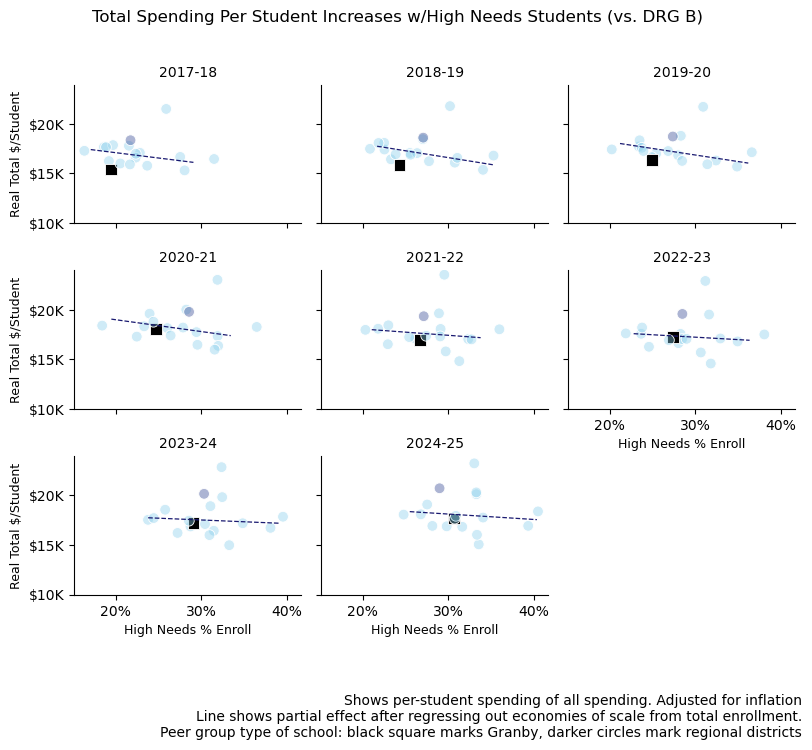

In [34]:
# limit to 12 years
g = sns.relplot(data=peer_combined,
                x='High Needs Students Share of Enrollment', y='Real PPE',
               col='Year', col_wrap=3,
               height=2.5, aspect=1.1, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f"Total Spending Per Student Increases w/High Needs Students (vs. {PEERTEXT})")
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='High Needs Students Share of Enrollment', y='Real PPE',
                x_partial='Enrollment',
                scatter=False, ci=None, robust=True, 
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_ylabels("Real Total $/Student", fontsize=9)
g.set_xlabels("High Needs % Enroll", fontsize=9)
for ax in g.axes.flat:
    ax.set_ylim(bottom=10000)
    #ax.set_xlim(right=13500)
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.88, bottom=0.2)

line1 = "Shows per-student spending of all spending. Adjusted for inflation\n"
line2 = "Line shows partial effect after regressing out economies of scale from total enrollment.\n"
line3 = "Peer group type of school: black square marks Granby, darker circles mark regional districts"

g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

#plt.savefig(f"./charts/staffing/{PEERVAR}/accountability_over_instructional.png", dpi=200, metadata=png_metadata)

plt.show()

## Staff Proportions

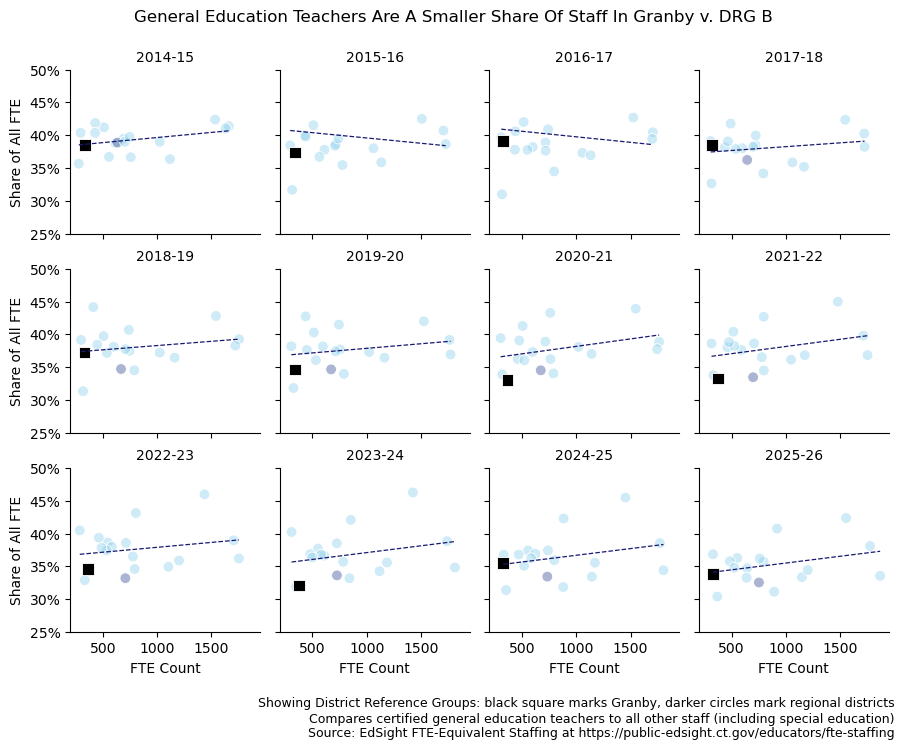

In [35]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               y='Teachers Share Of FTE', x='FTE Count',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f"General Education Teachers Are A Smaller Share Of Staff In Granby v. {PEERTEXT}")
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='FTE Count', y='Teachers Share Of FTE', scatter=False, ci=None,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set(ylim=(.25,.5))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.set_ylabel('Share of All FTE')

plt.subplots_adjust(top=.9, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Compares certified general education teachers to all other staff (including special education)\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/teacher_share_of_fte.png", dpi=200, metadata=png_metadata)

plt.show()

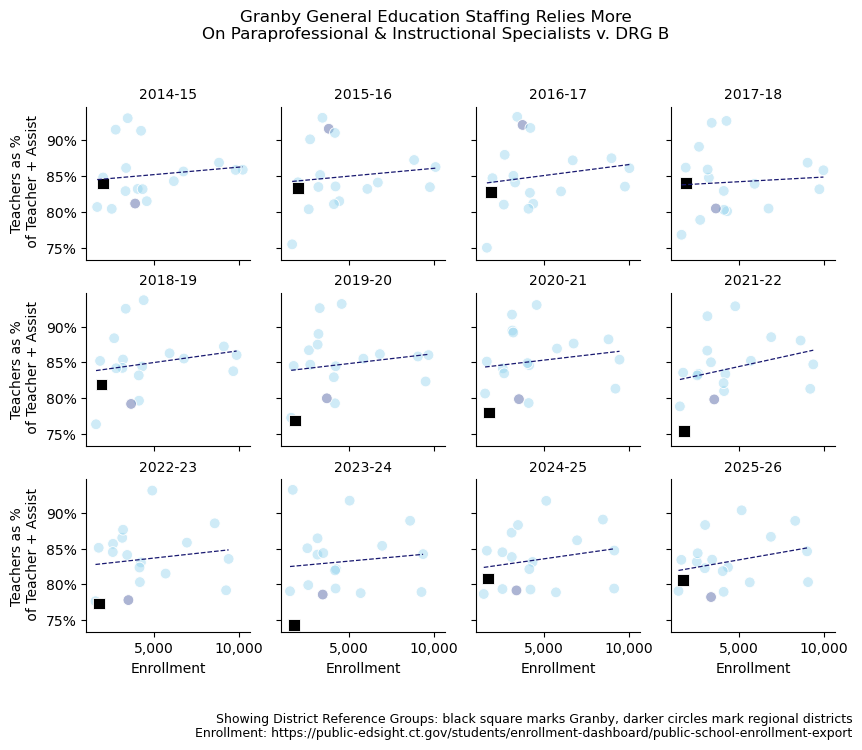

In [36]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Teachers Share of General Ed', 
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.figure.suptitle(f"Granby General Education Staffing Relies More\nOn Paraprofessional & Instructional Specialists v. {PEERTEXT}")
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot,x='Enrollment', y='Teachers Share of General Ed', scatter=False, ci=None,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})


g.set_ylabels(label='Teachers as %\n of Teacher + Assist')
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.85, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Enrollment: https://public-edsight.ct.gov/students/enrollment-dashboard/public-school-enrollment-export"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/teacher_share_of_gened.png", dpi=200, metadata=png_metadata)

plt.show()

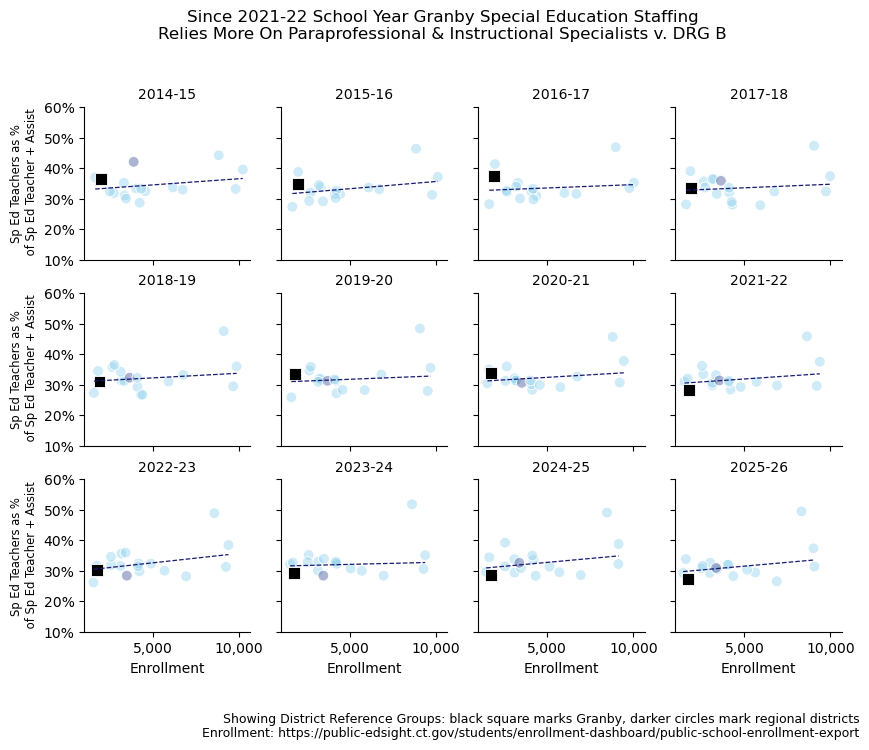

In [37]:

# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Teachers Share of Special Ed', 
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.figure.suptitle(f'Since 2021-22 School Year Granby Special Education Staffing\nRelies More On Paraprofessional & Instructional Specialists v. {PEERTEXT}')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot,x='Enrollment', y='Teachers Share of Special Ed',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})


g.set_ylabels(label='Sp Ed Teachers as %\n of Sp Ed Teacher + Assist', fontsize='small')
for ax in g.axes.flat:
    ax.set_ylim(.1, .6)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.85, bottom=0.15)
line1 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line2 = "Enrollment: https://public-edsight.ct.gov/students/enrollment-dashboard/public-school-enrollment-export"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/teacher_share_of_special_ed.png", dpi=200, metadata=png_metadata)

plt.show()

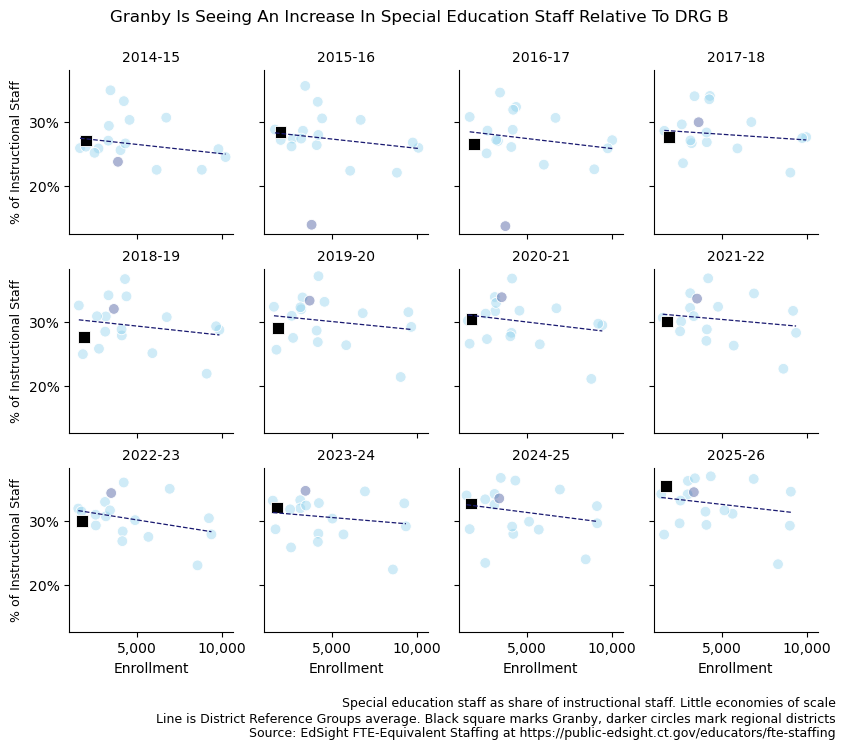

In [38]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
                x='Enrollment', y='Special Ed Share of Instructional',
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Is Seeing An Increase In Special Education Staff Relative To {PEERTEXT}')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Special Ed Share of Instructional',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_ylabels("% of Instructional Staff", fontsize=9)
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(comma)
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Line is District Reference Groups average. Black square marks Granby, darker circles mark regional districts\n"
line1 = "Special education staff as share of instructional staff. Little economies of scale\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/special_ed_share_of_staff.png", dpi=200, metadata=png_metadata)

plt.show()

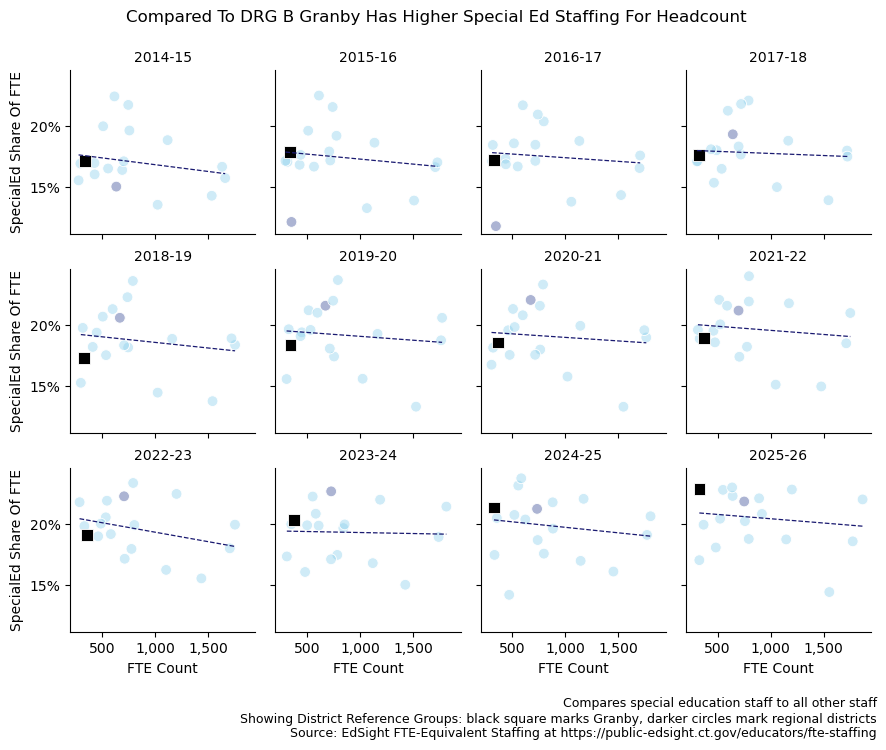

In [39]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='FTE Count', y='SpecialEd Share Of FTE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Compared To {PEERTEXT} Granby Has Higher Special Ed Staffing For Headcount')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='FTE Count', y='SpecialEd Share Of FTE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

#g.set(ylim=(0,.1))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line1 = "Compares special education staff to all other staff\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/specialed_share_of_fte.png", dpi=200, metadata=png_metadata)

plt.show()

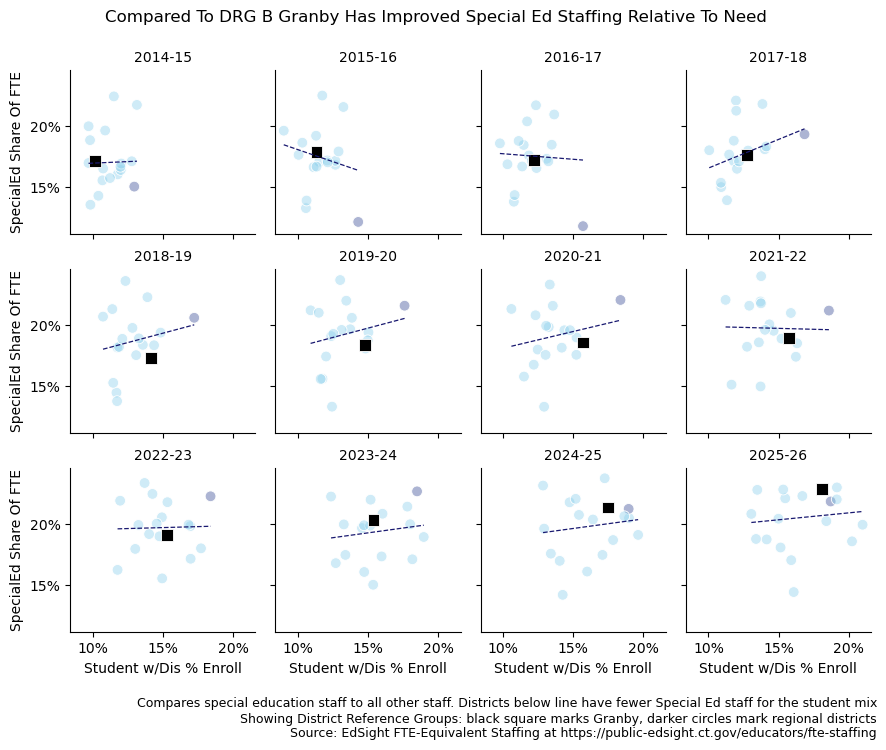

In [40]:

# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Students w/ Disabilities Share of Enrollment', y='SpecialEd Share Of FTE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Compared To {PEERTEXT} Granby Has Improved Special Ed Staffing Relative To Need')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, 
                x='Students w/ Disabilities Share of Enrollment', y='SpecialEd Share Of FTE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

#g.set(ylim=(0,.1))
g.set(xlabel="Student w/Dis % Enroll")

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(perci_formatter)
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Showing District Reference Groups: black square marks Granby, darker circles mark regional districts\n"
line1 = "Compares special education staff to all other staff. Districts below line have fewer Special Ed staff for the student mix\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/specialed_relative_to_need.png", dpi=200, metadata=png_metadata)
plt.show()

#### Administrators

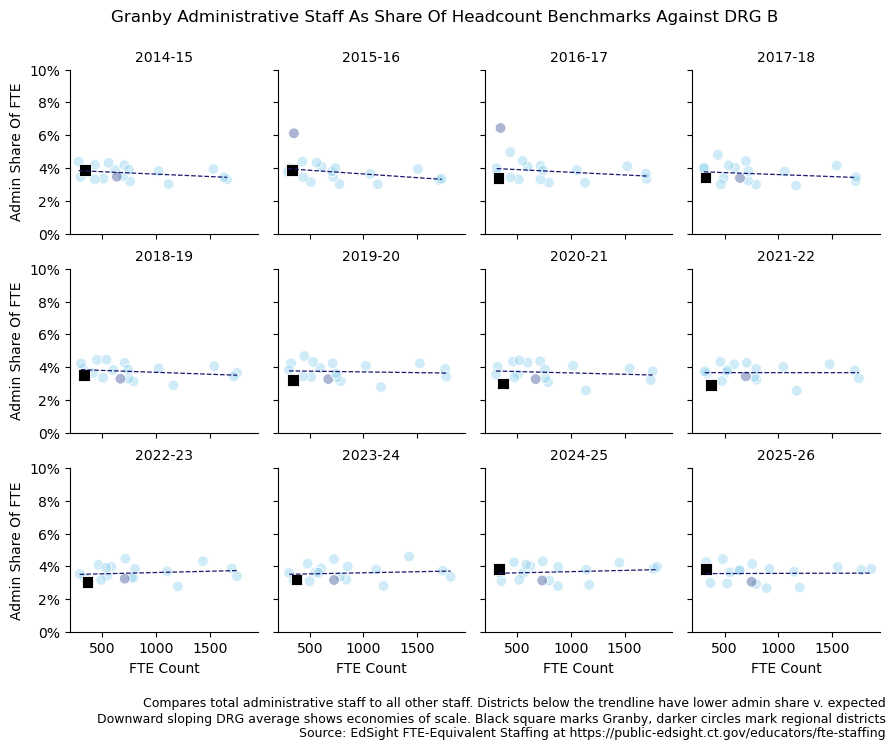

In [41]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='FTE Count', y='Admin Share Of FTE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Administrative Staff As Share Of Headcount Benchmarks Against {PEERTEXT}')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='FTE Count', y='Admin Share Of FTE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set(ylim=(0,.1))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Downward sloping DRG average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line1 = "Compares total administrative staff to all other staff. Districts below the trendline have lower admin share v. expected\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/admin_share_of_fte.png", dpi=200, metadata=png_metadata)

plt.show()

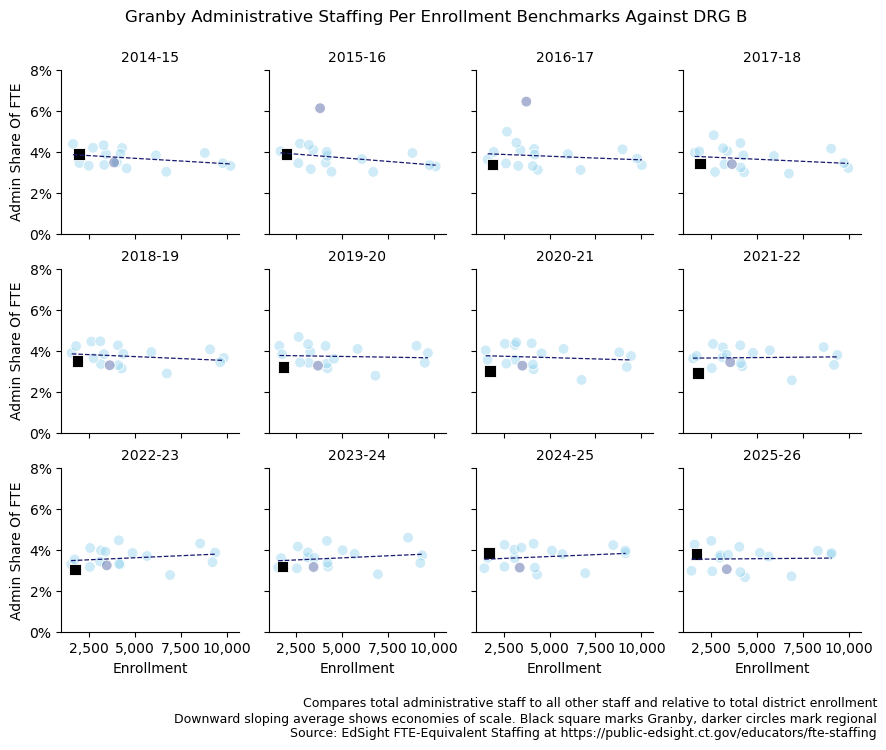

In [42]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Admin Share Of FTE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Administrative Staffing Per Enrollment Benchmarks Against {PEERTEXT}')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Admin Share Of FTE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set(ylim=(0,.08))

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)
    ax.yaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional\n"
line1 = "Compares total administrative staff to all other staff and relative to total district enrollment\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/admin_share_per_student.png", dpi=200, metadata=png_metadata)

plt.show()

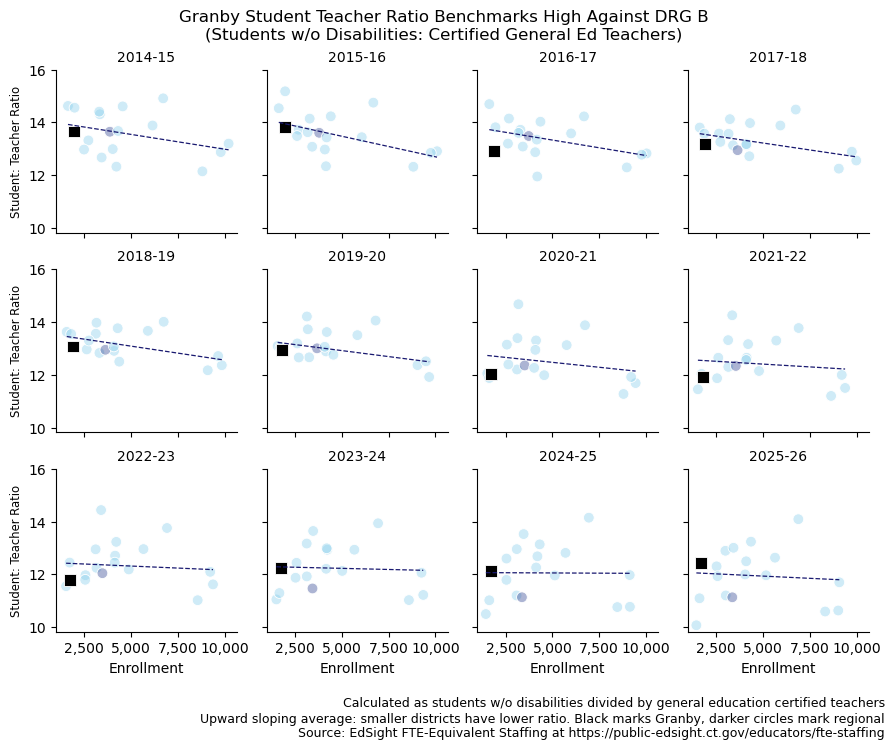

In [43]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y="Students w/o Disabilities: Teacher Ratio",
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Student Teacher Ratio Benchmarks High Against {PEERTEXT}\n(Students w/o Disabilities: Certified General Ed Teachers)')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y="Students w/o Disabilities: Teacher Ratio",
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_ylabels('Student: Teacher Ratio', fontsize='small')
for ax in g.axes.flat:
    ax.set_ylim(top=16)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Upward sloping average: smaller districts have lower ratio. Black marks Granby, darker circles mark regional\n"
line1 = "Calculated as students w/o disabilities divided by general education certified teachers\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/student_teacher_ratio_gened.png", dpi=200, metadata=png_metadata)

plt.show()

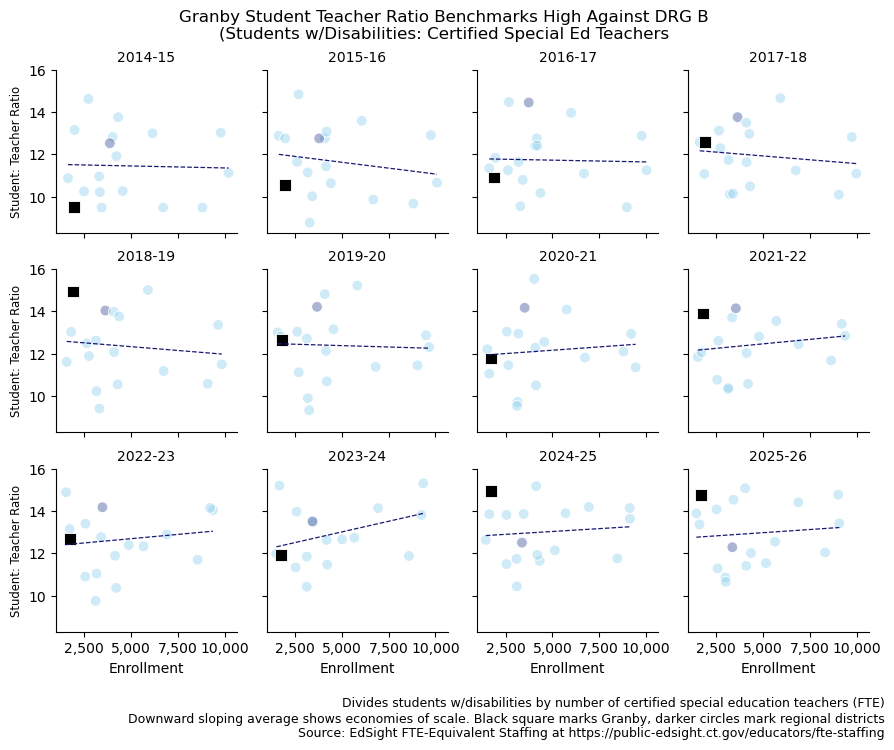

In [44]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y="Students w/ Disabilities: Teacher Ratio",
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Student Teacher Ratio Benchmarks High Against {PEERTEXT}\n(Students w/Disabilities: Certified Special Ed Teachers')
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y="Students w/ Disabilities: Teacher Ratio",
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_ylabels('Student: Teacher Ratio', fontsize='small')
for ax in g.axes.flat:
    ax.set_ylim(top=16)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line1 = "Divides students w/disabilities by number of certified special education teachers (FTE)\n"
line3 = "Source: EdSight FTE-Equivalent Staffing at https://public-edsight.ct.gov/educators/fte-staffing"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/staffing/{PEERVAR}/student_teacher_ratio_specialed.png", dpi=200, metadata=png_metadata)

plt.show()

## Retention Data
It might be useful to look at the different types of exits: how many are still teaching and how many are not. That could be a way of marking retirement.

One thing here - the staff reduction may be intentional.

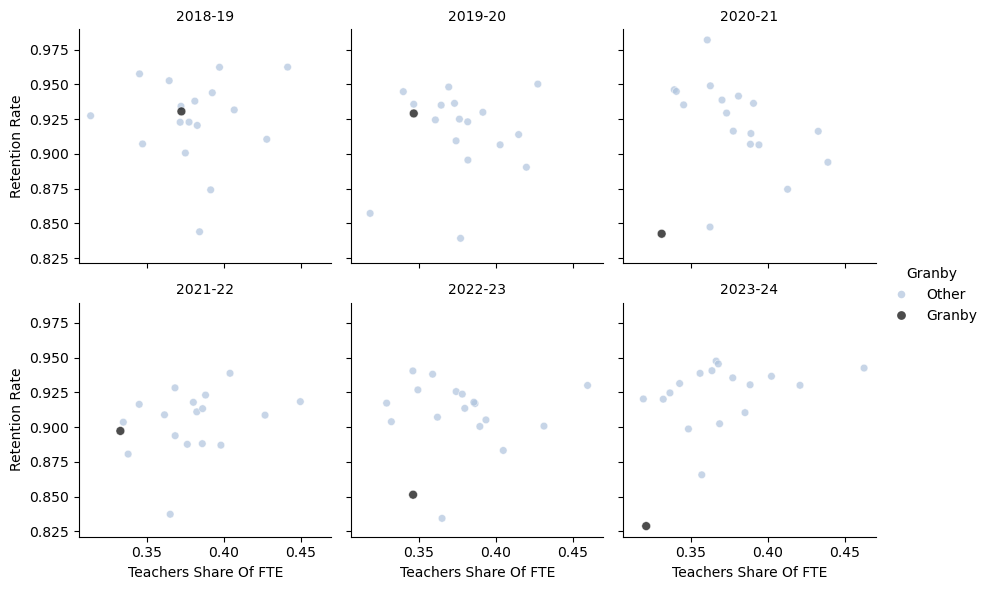

In [45]:
g = sns.relplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
                x='Teachers Share Of FTE', y='Retention Rate', col='Year', col_wrap=3, hue='Granby',
            style='Granby', size='Granby', alpha=.7, height=3, sizes=[30, 40], markers=['o', 'o'], palette=['lightsteelblue', 'black'])

g.set_titles("{col_name}")
plt.show()

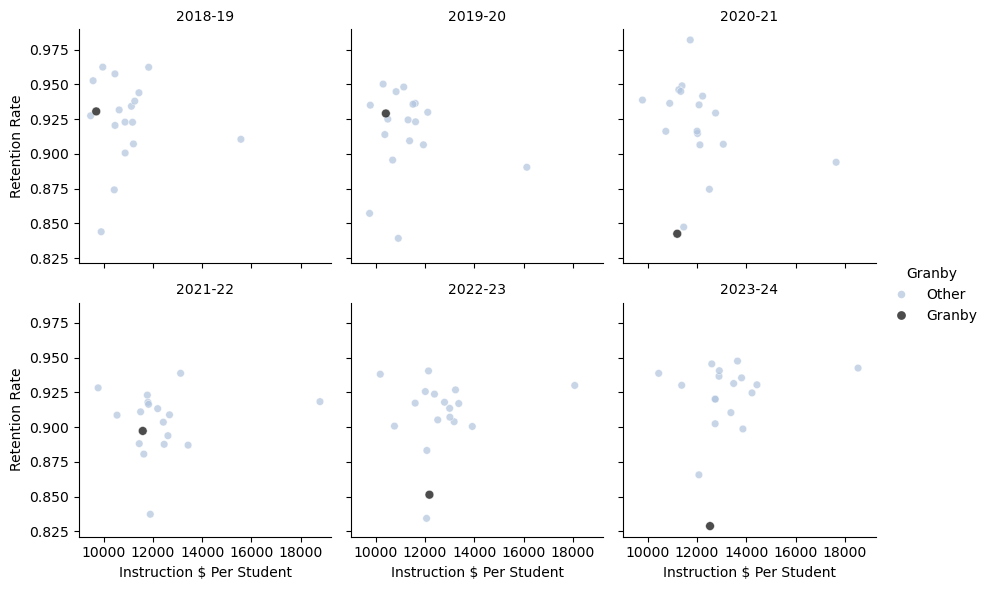

In [46]:
g = sns.relplot(data=peerstaff[(peerstaff['Year'] > '2018') & (peerstaff['Year'] < '2024')],
                x='Instruction $ Per Student', y='Retention Rate', col='Year', col_wrap=3, hue='Granby',
            style='Granby', size='Granby', alpha=.7, height=3, sizes=[30, 40], markers=['o', 'o'], palette=['lightsteelblue', 'black'])

g.set_titles("{col_name}")

## Expenditures
### Relative To Enrollment

In [47]:
peer_expenditures['Function'].value_counts()

Function
Instruction                                       234
Operation and maintenance of plant                234
Student transportation services                   234
Support services - general administration         234
Support services - instruction                    234
Support services - school based administration    234
Support services - students                       234
Central and other support services                144
Employee Benefits                                 144
Salaries                                          144
Services And Supplies                             144
Total                                             144
Tuitition                                         144
Administration and Support Services                90
Name: count, dtype: int64

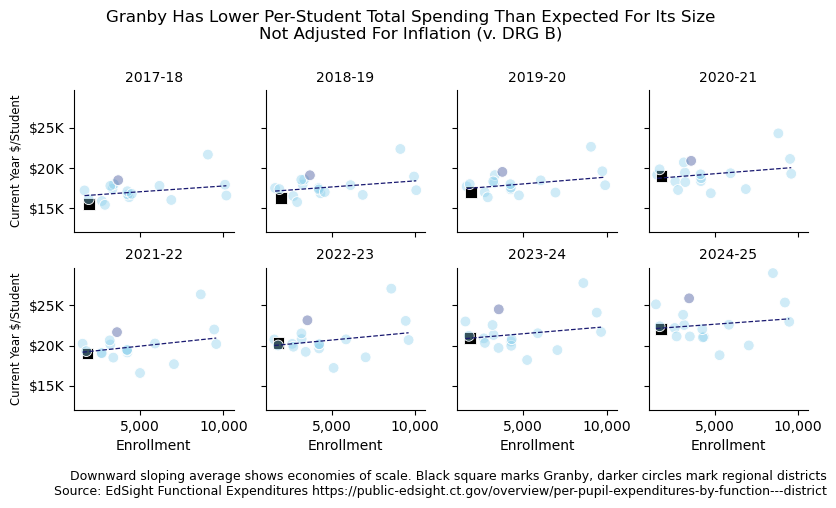

In [50]:
# limit to 12 years
g = sns.relplot(data=peer_expenditures[(peer_expenditures['Year'] >= sorted(peer_expenditures['Year'].unique())[-12:][0])
                            & (peer_expenditures['Function'] == 'Total')],
               x='Pupils', y='PPE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Has Lower Per-Student Total Spending Than Expected For Its Size\nNot Adjusted For Inflation (v. {PEERTEXT})')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Pupils', y='PPE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_xlabels("Enrollment")
for ax in g.axes.flat:
    ax.set_ylim(bottom=12000)
    ax.set_ylabel('Current Year $/Student', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.82, bottom=0.18)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line3 = "Source: EdSight Functional Expenditures https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/expenditures/{PEERVAR}/spend_v_enrollment.png", dpi=200, metadata=png_metadata)

plt.show()

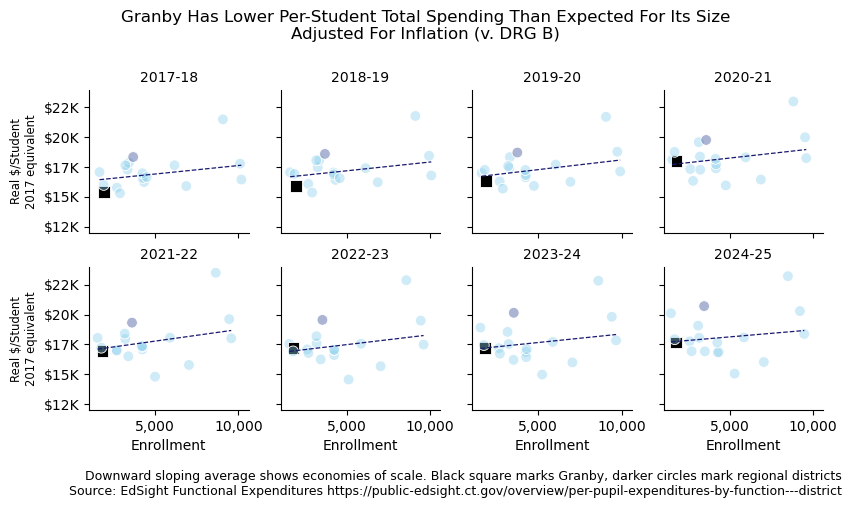

In [51]:
# limit to 12 years
g = sns.relplot(data=peer_expenditures[(peer_expenditures['Year'] >= sorted(peer_expenditures['Year'].unique())[-12:][0])
                            & (peer_expenditures['Function'] == 'Total')],
               x='Pupils', y='Real PPE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.85, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Has Lower Per-Student Total Spending Than Expected For Its Size\nAdjusted For Inflation (v. {PEERTEXT})')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Pupils', y='Real PPE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set_xlabels("Enrollment")
for ax in g.axes.flat:
    ax.set_ylim(bottom=12000)
    ax.set_ylabel('Real $/Student\n2017 equivalent', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

# for instructional $ plot
_bot, _top = g.axes.flat[0].get_ylim()
_range = _top - _bot

plt.subplots_adjust(top=.82, bottom=0.18)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line3 = "Source: EdSight Functional Expenditures https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/expenditures/{PEERVAR}/spend_v_enrollment_real.png", dpi=200, metadata=png_metadata)

plt.show()

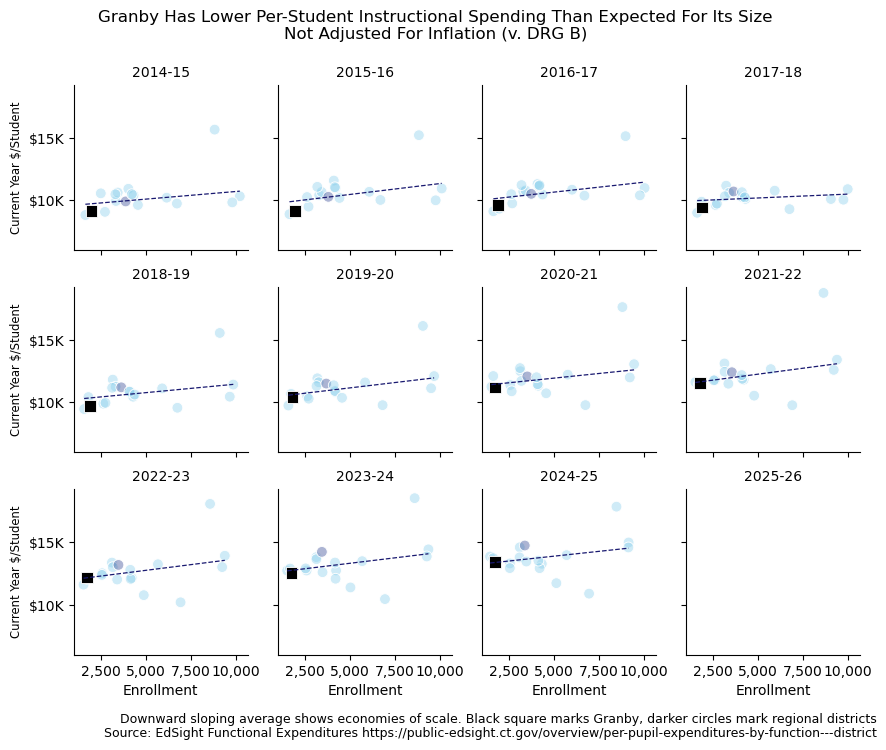

In [52]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Instruction $ Per Student',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Has Lower Per-Student Instructional Spending Than Expected For Its Size\nNot Adjusted For Inflation (v. {PEERTEXT})')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Instruction $ Per Student',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})


for ax in g.axes.flat:
    ax.set_ylim(bottom=6000)
    ax.set_ylabel('Current Year $/Student', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.88, bottom=0.12)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line3 = "Source: EdSight Functional Expenditures https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/expenditures/{PEERVAR}/instructional_v_enrollment.png", dpi=200, metadata=png_metadata)

plt.show()

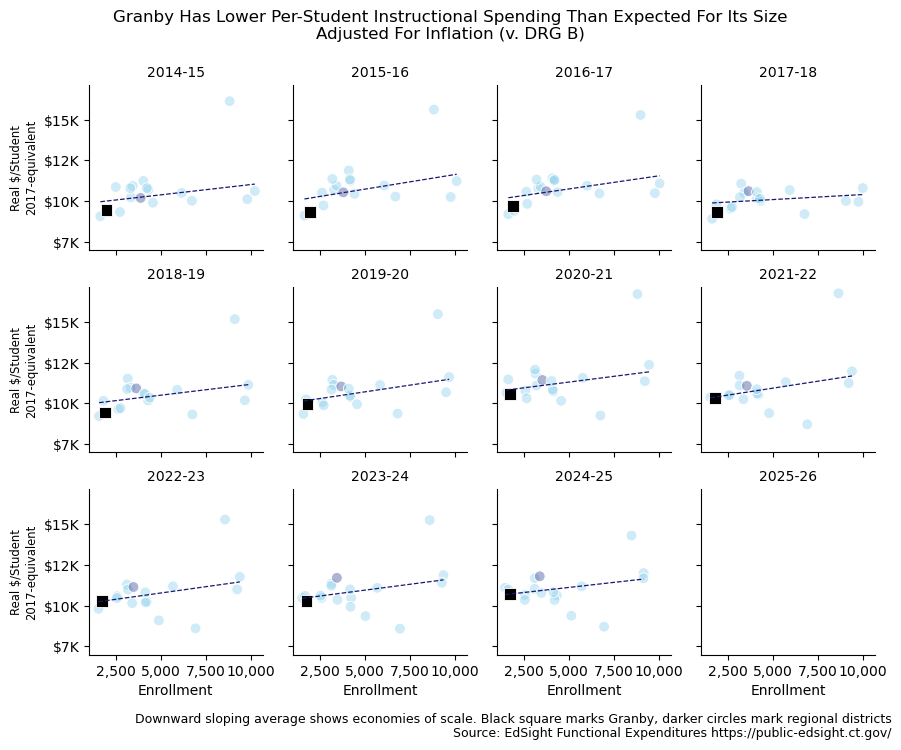

In [53]:
# limit to 12 years
g = sns.relplot(data=peerstaff[peerstaff['Year'] >= sorted(peerstaff['Year'].unique())[-12:][0]],
               x='Enrollment', y='Real Instruction $ Per Student',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Has Lower Per-Student Instructional Spending Than Expected For Its Size\nAdjusted For Inflation (v. {PEERTEXT})')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Real Instruction $ Per Student',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})


for ax in g.axes.flat:
    ax.set_ylim(bottom=7000)
    ax.set_ylabel('Real $/Student\n2017-equivalent', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.88, bottom=0.12)
line2 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional districts\n"
line3 = "Source: EdSight Functional Expenditures https://public-edsight.ct.gov/"
g.fig.text(.99, .01, line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/expenditures/{PEERVAR}/instructional_v_enrollment_real.png", dpi=200, metadata=png_metadata)

plt.show()

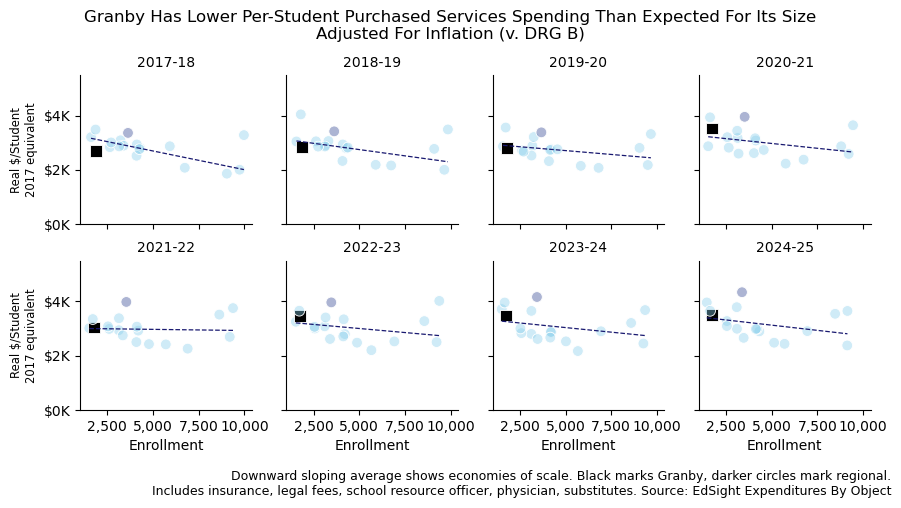

In [54]:
# limit to 12 years

g = sns.relplot(data=peer_combined[peer_combined['Year'] >= sorted(peer_combined['Year'].unique())[-12:][0]],
               x='Enrollment', y='Real Purchased Services Per Student',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Has Lower Per-Student Purchased Services Spending Than Expected For Its Size\nAdjusted For Inflation (v. {PEERTEXT})')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Real Purchased Services Per Student',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set(ylim=(0,5500))

for ax in g.axes.flat:
    #ax.set_ylim(bottom=4000, top=4000 + _range)
    ax.set_ylabel('Real $/Student\n2017 equivalent', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.85, bottom=0.18)
line1 = "Downward sloping average shows economies of scale. Black marks Granby, darker circles mark regional.\n"
line2 = "Includes insurance, legal fees, school resource officer, physician, substitutes. Source: EdSight Expenditures By Object"
g.fig.text(.99, .01, line1 + line2 , ha='right', fontsize=9)

plt.savefig(f"./charts/expenditures/{PEERVAR}/services_v_enrollment_real.png", dpi=200, metadata=png_metadata)

plt.show()

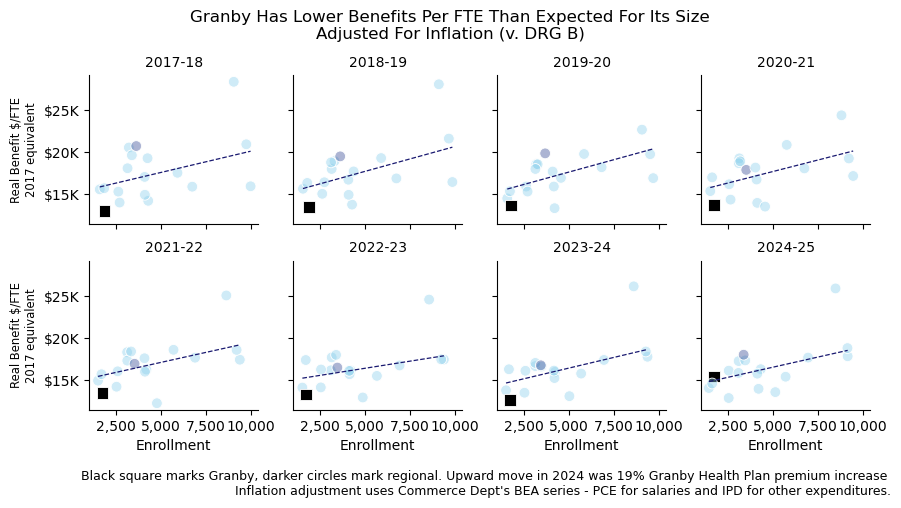

In [55]:
# limit to 12 years
g = sns.relplot(data=peer_combined[peer_combined['Year'] >= sorted(peer_combined['Year'].unique())[-12:][0]],
               x='Enrollment', y='Real Benefits Per FTE',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Has Lower Benefits Per FTE Than Expected For Its Size\nAdjusted For Inflation (v. {PEERTEXT})')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Real Benefits Per FTE',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

#g.set(ylim=(0,5000))

for ax in g.axes.flat:
    #ax.set_ylim(bottom=4000, top=4000 + _range)
    ax.set_ylabel('Real Benefit $/FTE\n2017 equivalent', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.85, bottom=0.18)
line1 = "Black square marks Granby, darker circles mark regional. Upward move in 2024 was 19% Granby Health Plan premium increase \n"
line2 = "Inflation adjustment uses Commerce Dept's BEA series - PCE for salaries and IPD for other expenditures."
line3 = "Source: EdSight Expenditures By Object https://public-edsight.ct.gov/"
g.fig.text(.99, .01, line1 + line2 , ha='right', fontsize=9)

plt.savefig(f"./charts/expenditures/{PEERVAR}/benefits_v_enrollment_real.png", dpi=200, metadata=png_metadata)

plt.show()

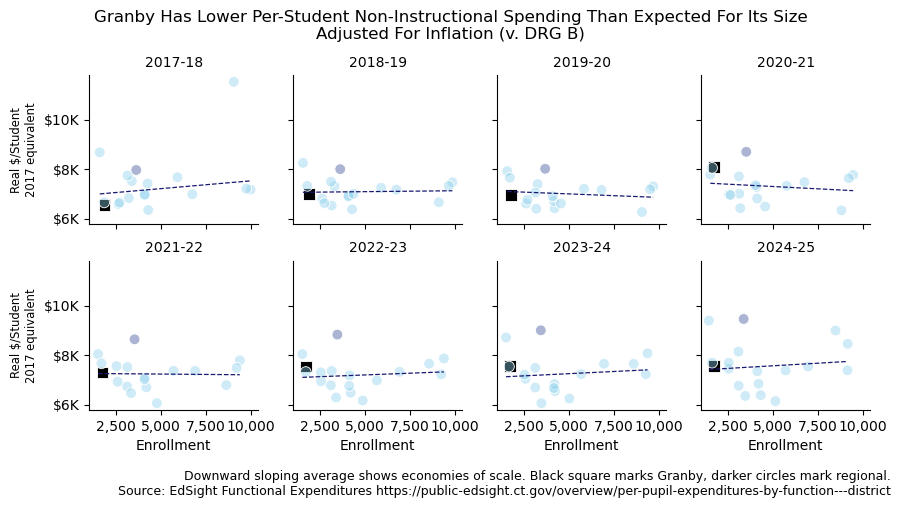

In [56]:
# limit to 12 years

g = sns.relplot(data=peer_combined[peer_combined['Year'] >= sorted(peer_combined['Year'].unique())[-12:][0]],
               x='Enrollment', y='Real Non-Instruction $ Per Student',
               col='Year', col_wrap=4,
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Granby Has Lower Per-Student Non-Instructional Spending Than Expected For Its Size\nAdjusted For Inflation (v. {PEERTEXT})')

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Enrollment', y='Real Non-Instruction $ Per Student',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

#g.set(ylim=(0,.1))

for ax in g.axes.flat:
    #ax.set_ylim(bottom=4000, top=4000 + _range)
    ax.set_ylabel('Real $/Student\n2017 equivalent', fontsize='small')
    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.xaxis.set_major_formatter(comma_formatter)

plt.subplots_adjust(top=.85, bottom=0.18)
line1 = "Downward sloping average shows economies of scale. Black square marks Granby, darker circles mark regional.\n"
line2 = "Source: EdSight Functional Expenditures https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 , ha='right', fontsize=9)

plt.savefig(f"./charts/expenditures/{PEERVAR}/noninstructional_v_enrollment_real.png", dpi=200, metadata=png_metadata)

plt.show()

## Per-Pupil Spending Model

In [57]:
# Key variables
# Convert to mean zero, unit std
_df = peer_combined[['Real PPE', 'High Needs Students Share of Enrollment', 'Students w/ Disabilities Share of Enrollment',
                     'Enrollment', '% w/Bachelors+', 'Income Per Taxpayer', '% Student', f"{PEERVAR}", 'Year', 'District', 'Granby']]\
                  .rename(columns={'Real PPE': 'RealPPE', 'Income Per Taxpayer': 'AveIncome',
                                   'Students w/ Disabilities Share of Enrollment': 'WithDisability',
                                   '% Student': 'StudentShare', '% w/Bachelors+': 'DegreeShare'}).copy()
# ESL, SNAP only
_df['HighNeeds'] = _df['High Needs Students Share of Enrollment'] - _df['WithDisability']

# center on zero, same var
for v in ['RealPPE', 'Enrollment', 'AveIncome', 'DegreeShare', 'StudentShare', 'WithDisability', 'HighNeeds']:
    _df[v] = (_df[v] - _df[v].mean()) / _df[v].std()

_df[['WithDisability', 'HighNeeds', 'StudentShare', 'Enrollment', 'AveIncome']].corr()


,WithDisability,HighNeeds,StudentShare,Enrollment,AveIncome
WithDisability,1.000000,0.068658,-0.318796,0.053196,0.011465
HighNeeds,0.068658,1.000000,-0.149842,0.345638,0.147423
StudentShare,-0.318796,-0.149842,1.000000,0.147289,-0.181416
Enrollment,0.053196,0.345638,0.147289,1.000000,0.494969
AveIncome,0.011465,0.147423,-0.181416,0.494969,1.000000


### District coefficients 
Estimate of the amount of spending above or below expectations (std deviations)

In [58]:
fullform = "Q('RealPPE') ~ C(District, Sum) + HighNeeds + WithDisability + Enrollment + AveIncome + DegreeShare + StudentShare"
form = "Q('RealPPE') ~ HighNeeds + WithDisability + Enrollment + AveIncome + DegreeShare + StudentShare"
#smf.rlm(form, data=_df, M=sm.robust.norms.HuberT()).fit().summary()

In [59]:
fullmodel = smf.ols(fullform, data=_df).fit()
fullmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Q('RealPPE')   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     119.5
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           2.32e-71
Time:                        00:40:05   Log-Likelihood:                 21.081
No. Observations:                 144   AIC:                             3.837
Df Residuals:                     121   BIC:                             72.14
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
=====================================================================================================================
                                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                          1.249e-16      0.019   6.57e-15      1.000      -0.038       0.038
C(District, Sum)[S.Avon School District]             -3.9316      0.840     -4.682      0.000      -5.594      -2.269
C(District, Sum)[S.Brookfield School District]       -0.2725      0.109     -2.502      0.014      -0.488      -0.057
C(District, Sum)[S.Canton School District]           -2.2369      0.558     -4.005      0.000      -3.343      -1.131
C(District, Sum)[S.Cheshire School District]         -1.6457      0.149    -11.017      0.000      -1.941      -1.350
C(District, Sum)[S.Fairfield School District]         3.6217      0.805      4.501      0.000       2.029       5.215
C(District, Sum)[S.Farmington School District]       -2.2892      0.347     -6.604      0.000      -2.975      -1.603
C(District, Sum)[S.Glastonbury School District]      -0.0961      0.099     -0.969      0.335      -0.292       0.100
C(District, Sum)[S.Granby School District]           -2.2927      0.522     -4.390      0.000      -3.327      -1.259
C(District, Sum)[S.Greenwich School District]         4.4723      0.732      6.113      0.000       3.024       5.921
C(District, Sum)[S.Guilford School District]         -0.9159      0.259     -3.537      0.001      -1.429      -0.403
C(District, Sum)[S.Monroe School District]            0.5153      0.186      2.767      0.007       0.147       0.884
C(District, Sum)[S.Oxford School District]            0.1821      0.107      1.708      0.090      -0.029       0.393
C(District, Sum)[S.Regional School District 15]       1.4245      0.258      5.515      0.000       0.913       1.936
C(District, Sum)[S.Rocky Hill School District]       -0.4259      0.200     -2.132      0.035      -0.821      -0.030
C(District, Sum)[S.Simsbury School District]         -2.5083      0.464     -5.402      0.000      -3.428      -1.589
C(District, Sum)[S.South Windsor School District]     0.6486      0.165      3.937      0.000       0.322       0.975
C(District, Sum)[S.Trumbull School District]          2.6102      0.439      5.941      0.000       1.740       3.480
HighNeeds                                             0.1688      0.050      3.353      0.001       0.069       0.268
WithDisability                                        0.0376      0.038      0.999      0.320      -0.037       0.112
Enrollment                                           -2.8543      0.610     -4.678      0.000      -4.062      -1.646
AveIncome                                            -0.1263      0.087     -1.456      0.148      -0.298       0.045
DegreeShare                                           2.2921      0.335      6.838      0.000       1.629       2.956
StudentShare   

### District-to-district differences are bulk of differences
But you can see large support: 7.9% of district-to-district variability is driven by % of Population w/Degrees

In [60]:
anovares = sm.stats.anova_lm(fullmodel, typ=2)
anovares['Share'] = anovares['sum_sq'] / anovares['sum_sq'].sum()
anovares

,sum_sq,df,F,PR(>F),Share
"C(District, Sum)",18.861173,17.0,21.339159,1.269879e-28,0.616548
HighNeeds,0.584667,1.0,11.245176,1.066214e-03,0.019112
WithDisability,0.051919,1.0,0.998583,3.196479e-01,0.001697
Enrollment,1.137575,1.0,21.879506,7.624618e-06,0.037186
AveIncome,0.110258,1.0,2.120641,1.479157e-01,0.003604
DegreeShare,2.431405,1.0,46.764346,3.487557e-10,0.079480
StudentShare,1.123468,1.0,21.608173,8.595197e-06,0.036725
Residual,6.291118,121.0,NaN,NaN,0.205649


### "Spending Over Expected"

In [61]:
# fit w/o district effects
spendingmodel = smf.ols(form, data=_df).fit()
predictions = spendingmodel.get_prediction(_df)
frame = predictions.summary_frame(alpha=0.05) 
_df = _df.join(frame)


spendingmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Q('RealPPE')   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     115.4
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           4.72e-51
Time:                        00:40:05   Log-Likelihood:                -74.195
No. Observations:                 144   AIC:                             162.4
Df Residuals:                     137   BIC:                             183.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1.249e-16      0.035   3.61e-15      1.000      -0.068       0.068
HighNeeds         -0.2603      0.041     -6.304      0.000      -0.342      -0.179
WithDisability     0.1698      0.037      4.534      0.000       0.096       0.244
Enrollment         0.1114      0.057      1.959      0.052      -0.001       0.224
AveIncome          0.5927      0.046     12.953      0.000       0.502       0.683
DegreeShare        0.1728      0.058      2.973      0.003       0.058       0.288
StudentShare      -0.4190      0.042     -9.903      0.000      -0.503      -0.335
==============================================================================
Omnibus:                        1.342   Durbin-Watson:                   1.681
Prob(Omnibus):                  0.511   Jarque-Bera (JB):                0.927
Skew:                          -0.071   Prob(JB):                        0.629
Kurtosis:                       3.366   Cond. No.                         3.29
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/Users/joel/opt/anaconda3/envs/base312/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
/Users/joel/opt/anaconda3/envs/base312/lib/python3.12/site-packages/statsmodels/robust/robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'


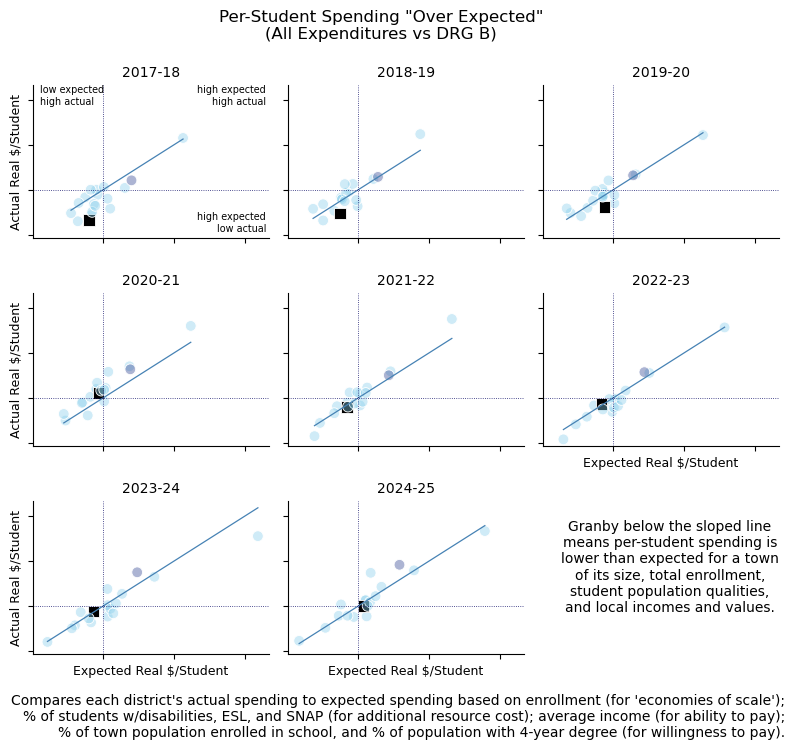

In [62]:
# limit to 12 years
g = sns.relplot(data=_df,
                x='mean', y='RealPPE',
               col='Year', col_wrap=3,
               height=2.5, aspect=1.1, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 72],
               hue = PEERVAR)

g.fig.suptitle(f'Per-Student Spending "Over Expected"\n(All Expenditures vs {PEERTEXT})')
g.set_titles(col_template="{col_name}")

g.map_dataframe(sns.regplot, x='mean', y='mean',
                scatter=False, ci=None, robust=True, 
                line_kws={'ls': '-', 'color': 'steelblue', 'lw': .9})

g.set_ylabels("Actual Real $/Student", fontsize=9)
g.set_xlabels("Expected Real $/Student", fontsize=9)

def hilo(x):
    print(str(x), x.find('-'))
    if x.find('-') >= 0:
        return 'Below'
    elif float(x) > 0:
        return 'Above'

plt.draw()
ax = g.axes.flat[0]
ax.text(0.03,1, 'low expected\nhigh actual', fontsize='x-small',
        transform=ax.transAxes, va='top')
ax.text(0.99,1, 'high expected\nhigh actual', fontsize='x-small',
        transform=ax.transAxes, va='top', ha='right')
ax.text(0.99,.03, 'high expected\nlow actual', fontsize='x-small',
        transform=ax.transAxes, va='bottom', ha='right')

for ax in g.axes.flat:
    ax.axhline(y=0, color='midnightblue', linestyle=':', lw=.6)
    ax.axvline(x=0, color='midnightblue', linestyle=':', lw=.6)
    #ax.set_ylim(bottom=10000)
    #ax.set_xlim(right=13500)
    #ax.yaxis.set_major_formatter(dollar_k_formatter)
    #ax.xaxis.set_major_formatter(dollar_k_formatter)

    # no zero
    labels = ax.yaxis.get_ticklabels()
    for label in labels:
        label.set_visible(False)
    labels = ax.xaxis.get_ticklabels()
    for label in labels:
        label.set_visible(False)

plt.subplots_adjust(top=.88, bottom=0.12)

n1 = 'Granby below the sloped line\n'
n2 = 'means per-student spending is\n'
n3 = 'lower than expected for a town\n'
n4 = 'of its size, total enrollment,\n'
n5 = 'student population qualities,\n'
n6 = 'and local incomes and values.'
g.fig.text(.85, .3, n1 + n2 + n3 + n4 + n5 + n6, va='top', ha='center')

line1 = "Compares each district's actual spending to expected spending based on enrollment (for 'economies of scale');\n"
line2 = "% of students w/disabilities, ESL, and SNAP (for additional resource cost); average income (for ability to pay);\n"
line3 = "% of town population enrolled in school, and % of population with 4-year degree (for willingness to pay)."
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)

plt.savefig(f"./charts/expenditures/{PEERVAR}/total_spend_over_expected.png", dpi=200, metadata=png_metadata)

plt.show()